# Anterior Eye Disease Detection (YOLOv8 + CBAM + Grad-CAM)
Notebook ini dioptimalkan untuk workflow riset yang **visual, rapih, dan paper-ready**.

Alur utama:
1. Setup environment
2. Validasi struktur dataset YOLO + visual quality check
3. Data cleaning ringan (blur/label check) + enhancement (CLAHE + sharpen ringan)
4. Controlled augmentation (brightness/contrast + rotasi kecil)
5. Integrasi CBAM native ke backbone (bukan hook)
6. Training strategy (AdamW + cosine annealing + early stopping)
7. Evaluasi lengkap (mAP, precision, recall, F1, confusion matrix)
8. Inference gallery
9. Grad-CAM untuk explainability
10. Export ONNX

> Asumsi: dataset zip/folder tersedia di `/content/dataset`.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================
# 1) Install dependencies (Colab)
# ==========================================
# Jika gagal karena jaringan Colab, rerun cell ini sekali.
!pip -q install ultralytics==8.2.103 grad-cam==1.5.4 onnx onnxruntime seaborn pyyaml albumentations==1.4.18 tqdm

import platform
import sys
print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 10.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.1/875.1 kB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 14.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follow

In [ ]:
!pip install albumentations==1.3.1 opencv-python-headless --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 5.4 MB/s eta 0:00:00


In [ ]:
!pip install numpy==1.26.4 pandas==2.2.2 --force-reinstall --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 175.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 170.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 277.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.0/349.0 kB 277.5 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2026.1
    Uninstalling tzdata-2026.1:
      Successfully uninstalled tzdata-2026.1
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.

In [ ]:
# ==========================================
# 2) Imports, reproducibility, and style
# ==========================================
import os
import random
import shutil
import warnings
import zipfile
from pathlib import Path
from typing import Dict, List, Optional, Tuple


import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import yaml
from PIL import Image
from IPython.display import display, Markdown
from tqdm.auto import tqdm

from ultralytics import YOLO
from ultralytics.utils import checks

# Sanity check
checks.check_yolo()

# Visual style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# Reproducibility
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device setup
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cpu":
    warnings.warn("CUDA tidak tersedia. Training pada CPU akan lambat.")
else:
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.8/112.6 GB disk)
Using device: cuda:0
GPU: Tesla T4


In [ ]:
# ==========================================
# 3) Dataset extraction + validation utilities
# ==========================================
DATASET_INPUT = Path("/content/drive/MyDrive/umn.v5i.yolov8-20260408T030729Z-3-001")
EXTRACT_ROOT = Path("/content/drive/MyDrive/umn.v5i.yolov8-20260408T030729Z-3-001")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def _is_yolo_split(root: Path, split: str) -> bool:
    return (root / split / "images").is_dir() and (root / split / "labels").is_dir()


def is_yolo_dataset_root(root: Path) -> bool:
    return all(_is_yolo_split(root, s) for s in ("train", "valid", "test"))


def find_dataset_root(search_dir: Path) -> Optional[Path]:
    if not search_dir.exists():
        return None
    candidates = []
    for p in search_dir.rglob("*"):
        if p.is_dir() and is_yolo_dataset_root(p):
            candidates.append(p)
    if is_yolo_dataset_root(search_dir):
        candidates.insert(0, search_dir)
    if not candidates:
        return None
    candidates = sorted(set(candidates), key=lambda x: (len(x.parts), str(x)))
    return candidates[0]


def extract_zip(zip_path: Path, dst_dir: Path) -> Path:
    if not zip_path.exists():
        raise FileNotFoundError(f"Zip file not found: {zip_path}")
    if not zipfile.is_zipfile(zip_path):
        raise ValueError(f"Provided file is not a valid zip archive: {zip_path}")

    dst_dir.mkdir(parents=True, exist_ok=True)
    target_dir = dst_dir / zip_path.stem
    target_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(target_dir)

    return target_dir


def resolve_dataset_root(input_path: Path, extract_root: Path) -> Path:
    if not input_path.exists():
        raise FileNotFoundError(
            f"Dataset path not found: {input_path}. Upload your dataset zip to this path first."
        )

    # Case A: input is already a YOLO root directory
    if input_path.is_dir() and is_yolo_dataset_root(input_path):
        return input_path

    # Case B: input is a zip file
    if input_path.is_file():
        extracted_dir = extract_zip(input_path, extract_root)
        root = find_dataset_root(extracted_dir)
        if root is None:
            raise RuntimeError(
                f"Could not find YOLO dataset structure after extraction: {extracted_dir}"
            )
        return root

    # Case C: input is a directory that may contain zip(s) or nested dataset
    if input_path.is_dir():
        nested_root = find_dataset_root(input_path)
        if nested_root is not None:
            return nested_root

        zip_candidates = sorted([p for p in input_path.glob("*.zip") if p.is_file()])
        if not zip_candidates:
            raise RuntimeError(
                f"No YOLO dataset folders and no zip files found in: {input_path}"
            )
        if len(zip_candidates) > 1:
            warnings.warn(
                f"Multiple zip files found in {input_path}. Using first one: {zip_candidates[0].name}"
            )

        extracted_dir = extract_zip(zip_candidates[0], extract_root)
        root = find_dataset_root(extracted_dir)
        if root is None:
            raise RuntimeError(
                f"Could not find YOLO dataset structure after extracting: {zip_candidates[0]}"
            )
        return root

    raise RuntimeError("Unsupported dataset input state.")


def split_stats(root: Path, split: str) -> Dict[str, object]:
    img_dir = root / split / "images"
    lbl_dir = root / split / "labels"

    images = [p for p in img_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS]
    labels = [p for p in lbl_dir.rglob("*.txt")]

    img_stems = {p.stem for p in images}
    lbl_stems = {p.stem for p in labels}

    missing_labels = sorted(img_stems - lbl_stems)
    orphan_labels = sorted(lbl_stems - img_stems)

    return {
        "split": split,
        "images": len(images),
        "labels": len(labels),
        "missing_labels": missing_labels,
        "orphan_labels": orphan_labels,
    }


def validate_dataset(root: Path) -> pd.DataFrame:
    if not is_yolo_dataset_root(root):
        raise RuntimeError(f"Invalid YOLO dataset structure at: {root}")

    stats = [split_stats(root, s) for s in ("train", "valid", "test")]
    df = pd.DataFrame([
        {
            "split": s["split"],
            "images": s["images"],
            "labels": s["labels"],
            "missing_labels": len(s["missing_labels"]),
            "orphan_labels": len(s["orphan_labels"]),
        }
        for s in stats
    ])

    for s in stats:
        if s["missing_labels"]:
            print(f"[WARN] {s['split']}: {len(s['missing_labels'])} images missing labels.")
            print("       Examples:", s["missing_labels"][:5])
        if s["orphan_labels"]:
            print(f"[WARN] {s['split']}: {len(s['orphan_labels'])} orphan label files.")
            print("       Examples:", s["orphan_labels"][:5])

    return df


def load_class_info(root: Path) -> Tuple[List[str], int]:
    data_yaml = root / "data.yaml"
    if not data_yaml.exists():
        raise FileNotFoundError(
            f"Missing data.yaml at dataset root: {data_yaml}. Please include Roboflow data.yaml."
        )

    with open(data_yaml, "r", encoding="utf-8") as f:
        data_cfg = yaml.safe_load(f)

    names = data_cfg.get("names")
    nc = data_cfg.get("nc")

    if names is None:
        if nc is None:
            raise RuntimeError("data.yaml must contain at least one of: 'names' or 'nc'.")
        names = [f"class_{i}" for i in range(int(nc))]
    elif isinstance(names, dict):
        names = [names[k] for k in sorted(names.keys(), key=int)]
    elif isinstance(names, list):
        names = [str(x) for x in names]
    else:
        raise TypeError("Unsupported 'names' format in data.yaml.")

    if nc is not None and int(nc) != len(names):
        warnings.warn(
            f"nc ({nc}) != len(names) ({len(names)}). Using len(names) for safety."
        )

    return names, len(names)


def write_colab_data_yaml(root: Path, names: List[str], out_path: Path) -> Path:
    cfg = {
        "path": str(root.resolve()),
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "nc": len(names),
        "names": names,
    }
    with open(out_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(cfg, f, sort_keys=False)
    return out_path


In [ ]:
# ==========================================
# 4) Resolve dataset path and build Colab data.yaml
# ==========================================
try:
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
    DATASET_ROOT = resolve_dataset_root(DATASET_INPUT, EXTRACT_ROOT)
    print(f"Dataset root: {DATASET_ROOT}")

    dataset_df = validate_dataset(DATASET_ROOT)
    display(dataset_df)

    CLASS_NAMES, NUM_CLASSES = load_class_info(DATASET_ROOT)
    print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

    COLAB_DATA_YAML = Path("/content/eye_disease_data_colab.yaml")
    COLAB_DATA_YAML = write_colab_data_yaml(DATASET_ROOT, CLASS_NAMES, COLAB_DATA_YAML)
    print(f"Generated training config: {COLAB_DATA_YAML}")

except Exception as e:
    raise RuntimeError(f"Dataset preparation failed: {e}")


Dataset root: /content/drive/MyDrive/umn.v5i.yolov8-20260408T030729Z-3-001/umn.v5i.yolov8


,split,images,labels,missing_labels,orphan_labels
0,train,2015,2015,0,0
1,valid,86,86,0,0
2,test,86,86,0,0


Classes (5): ['Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis', 'cataract']
Generated training config: /content/eye_disease_data_colab.yaml


### Distribusi kelas per split

split,test,train,valid
class,,,
Conjunctivitis,24,1877,31
Eyelid,19,1281,19
Normal,20,1318,14
Uveitis,5,748,10
cataract,25,2502,36


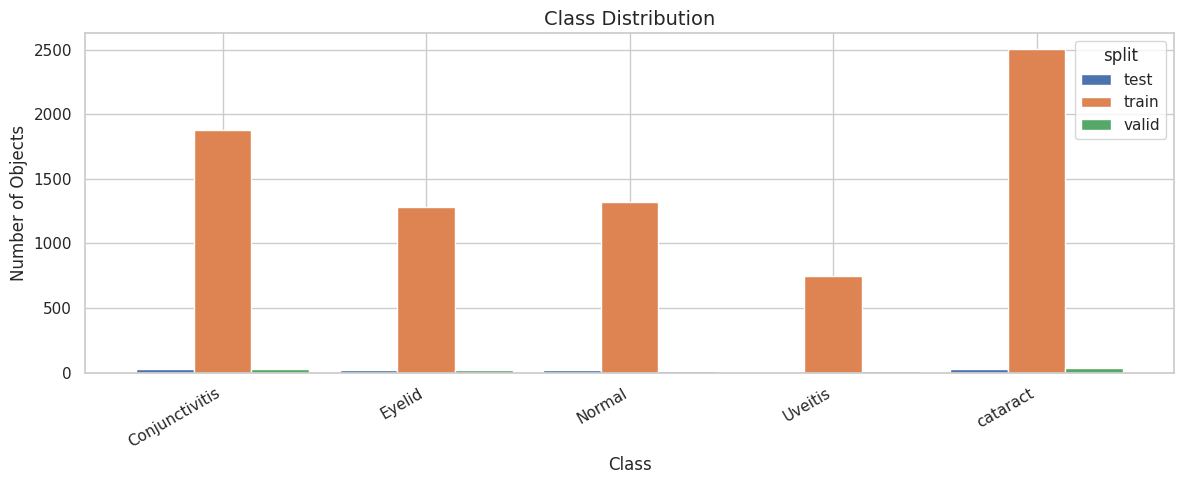

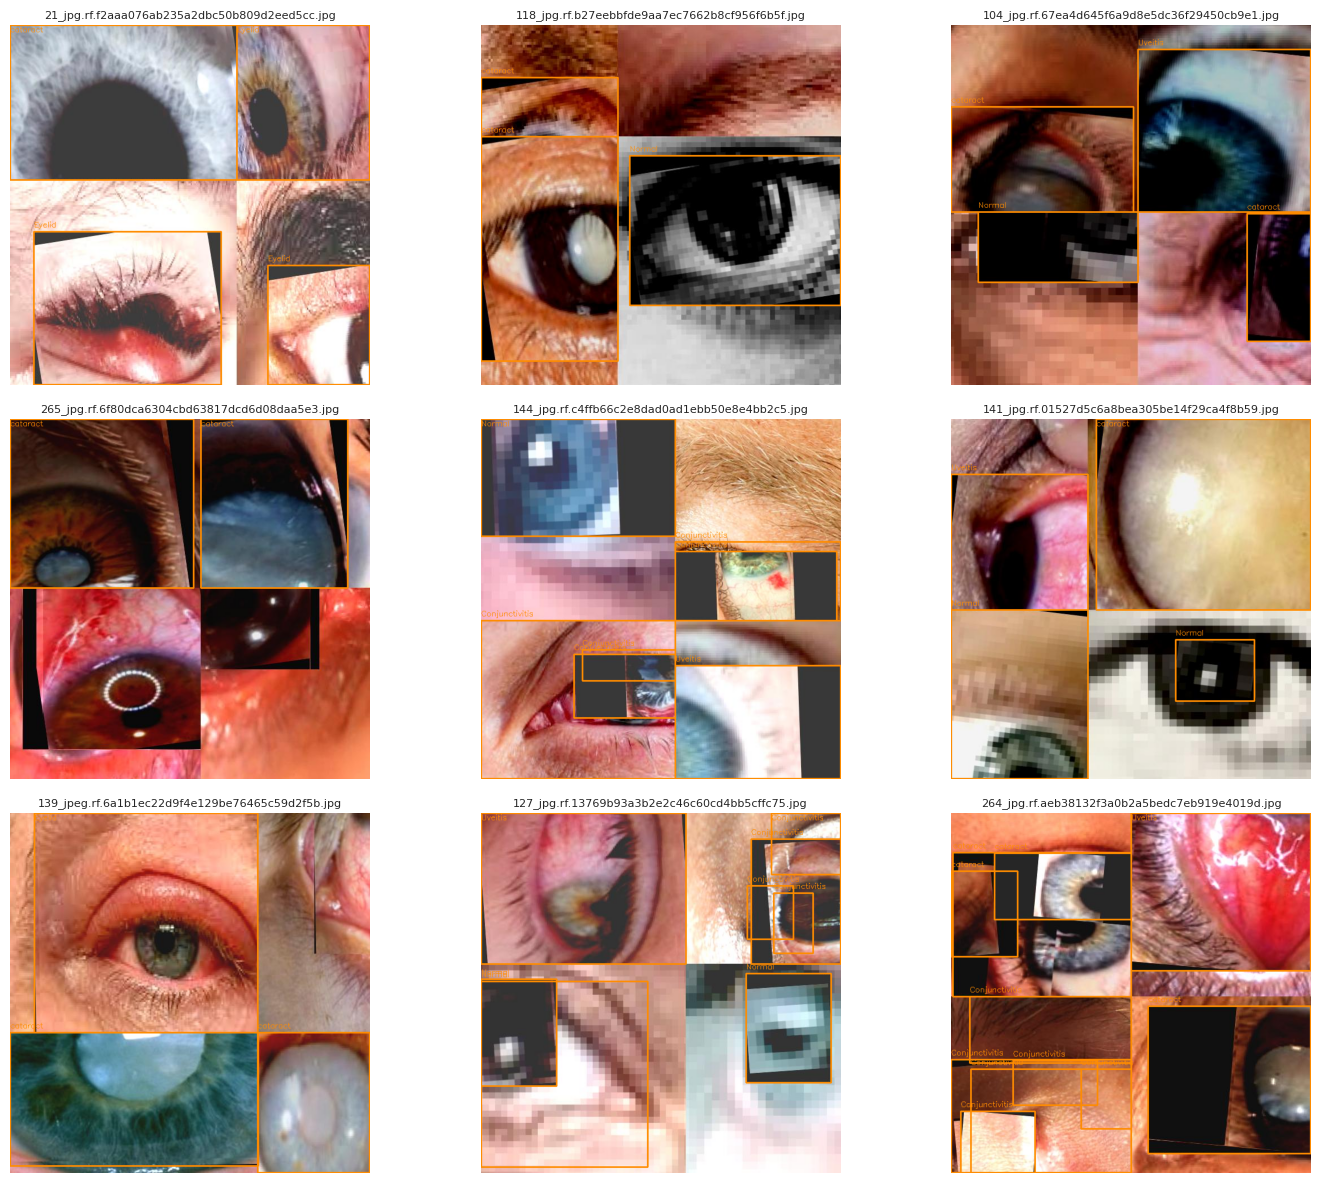

Blur scan train:   0%|          | 0/2015 [00:00<?, ?it/s]

Suggested blur threshold (10th percentile): 70.30


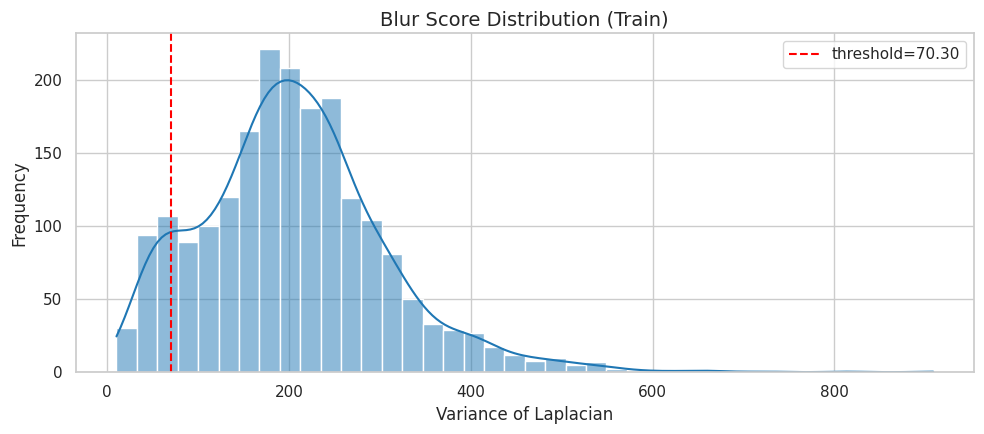

### Kandidat gambar blur (skor terendah)

,path,blur
435,/content/drive/MyDrive/umn.v5i.yolov8-20260408...,10.145557
454,/content/drive/MyDrive/umn.v5i.yolov8-20260408...,11.835996
1308,/content/drive/MyDrive/umn.v5i.yolov8-20260408...,13.725043
682,/content/drive/MyDrive/umn.v5i.yolov8-20260408...,15.359373
807,/content/drive/MyDrive/umn.v5i.yolov8-20260408...,18.618594
432,/content/drive/MyDrive/umn.v5i.yolov8-20260408...,19.459304
137,/content/drive/MyDrive/umn.v5i.yolov8-20260408...,20.051897
492,/content/drive/MyDrive/umn.v5i.yolov8-20260408...,21.216098
121,/content/drive/MyDrive/umn.v5i.yolov8-20260408...,22.321396
1529,/content/drive/MyDrive/umn.v5i.yolov8-20260408...,22.464846


In [ ]:
# ==========================================
# 4b) Visual QA dashboard (dataset quality)
# ==========================================
def get_split_images(root: Path, split: str):
    d = root / split / "images"
    return sorted([p for p in d.rglob("*") if p.suffix.lower() in IMAGE_EXTS])


def read_label_entries(label_path: Path):
    if not label_path.exists():
        return []
    out = []
    for line in label_path.read_text(encoding="utf-8").splitlines():
        sp = line.strip().split()
        if len(sp) != 5:
            continue
        try:
            c = int(float(sp[0]))
            x, y, w, h = map(float, sp[1:])
            out.append((c, x, y, w, h))
        except Exception:
            continue
    return out


def draw_boxes(rgb, entries, class_names):
    h, w = rgb.shape[:2]
    out = rgb.copy()
    for c, x, y, bw, bh in entries:
        x1 = int((x - bw / 2) * w)
        y1 = int((y - bh / 2) * h)
        x2 = int((x + bw / 2) * w)
        y2 = int((y + bh / 2) * h)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w - 1, x2), min(h - 1, y2)
        cv2.rectangle(out, (x1, y1), (x2, y2), (255, 140, 0), 2)
        name = class_names[c] if 0 <= c < len(class_names) else f"cls_{c}"
        cv2.putText(out, name, (x1, max(y1 - 8, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 140, 0), 1)
    return out


def blur_score(rgb):
    g = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    return float(cv2.Laplacian(g, cv2.CV_64F).var())


def collect_class_dist(root: Path, class_names):
    rec = []
    for sp in ("train", "valid", "test"):
        ldir = root / sp / "labels"
        for lf in ldir.glob("*.txt"):
            for c, *_ in read_label_entries(lf):
                rec.append({"split": sp, "class": class_names[c] if 0 <= c < len(class_names) else f"cls_{c}"})
    if not rec:
        return pd.DataFrame(columns=["split", "class", "count"])
    df = pd.DataFrame(rec)
    return df.value_counts(["split", "class"]).reset_index(name="count")


# Class distribution
class_dist = collect_class_dist(DATASET_ROOT, CLASS_NAMES)
if class_dist.empty:
    warnings.warn("Class distribution kosong. Periksa label dataset.")
else:
    pivot = class_dist.pivot_table(index="class", columns="split", values="count", aggfunc="sum", fill_value=0)
    pivot = pivot.reindex(CLASS_NAMES).fillna(0)
    display(Markdown("### Distribusi kelas per split"))
    display(pivot.style.format("{:.0f}").background_gradient(cmap="YlGnBu"))

    ax = pivot.plot(kind="bar", figsize=(12, 5), width=0.85)
    ax.set_title("Class Distribution")
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of Objects")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


train_images = get_split_images(DATASET_ROOT, "train")
if train_images:
    chosen = random.sample(train_images, min(9, len(train_images)))
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    for ax, img_path in zip(axes, chosen):
        bgr = cv2.imread(str(img_path))
        if bgr is None:
            ax.axis("off")
            continue
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        lbl = DATASET_ROOT / "train" / "labels" / f"{img_path.stem}.txt"
        entries = read_label_entries(lbl)
        vis = draw_boxes(rgb, entries, CLASS_NAMES)
        ax.imshow(vis)
        ax.set_title(img_path.name, fontsize=8)
        ax.axis("off")

    for ax in axes[len(chosen):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Blur distribution + suggestion threshold
if train_images:
    blur_rows = []
    for pth in tqdm(train_images, desc="Blur scan train"):
        bgr = cv2.imread(str(pth))
        if bgr is None:
            continue
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        blur_rows.append({"path": str(pth), "blur": blur_score(rgb)})

    blur_df = pd.DataFrame(blur_rows)
    if not blur_df.empty:
        BLUR_SUGGESTED_THRESHOLD = float(np.percentile(blur_df["blur"], 10))
        print(f"Suggested blur threshold (10th percentile): {BLUR_SUGGESTED_THRESHOLD:.2f}")

        plt.figure(figsize=(10, 4.5))
        sns.histplot(blur_df["blur"], bins=40, kde=True, color="#1f77b4")
        plt.axvline(BLUR_SUGGESTED_THRESHOLD, color="red", linestyle="--", label=f"threshold={BLUR_SUGGESTED_THRESHOLD:.2f}")
        plt.title("Blur Score Distribution (Train)")
        plt.xlabel("Variance of Laplacian")
        plt.ylabel("Frequency")
        plt.legend()
        plt.tight_layout()
        plt.show()

        display(Markdown("### Kandidat gambar blur (skor terendah)"))
        display(blur_df.sort_values("blur").head(15))


Preparing dataset: 100%|██████████| 212/212 [00:10<00:00, 19.56it/s]


### Distribusi kelas setelah preprocessing + oversampling

split,test,train,valid
class,,,
Conjunctivitis,182,3240,130
Eyelid,144,2100,125
Normal,123,2206,126
Uveitis,77,1200,86
cataract,256,4066,274


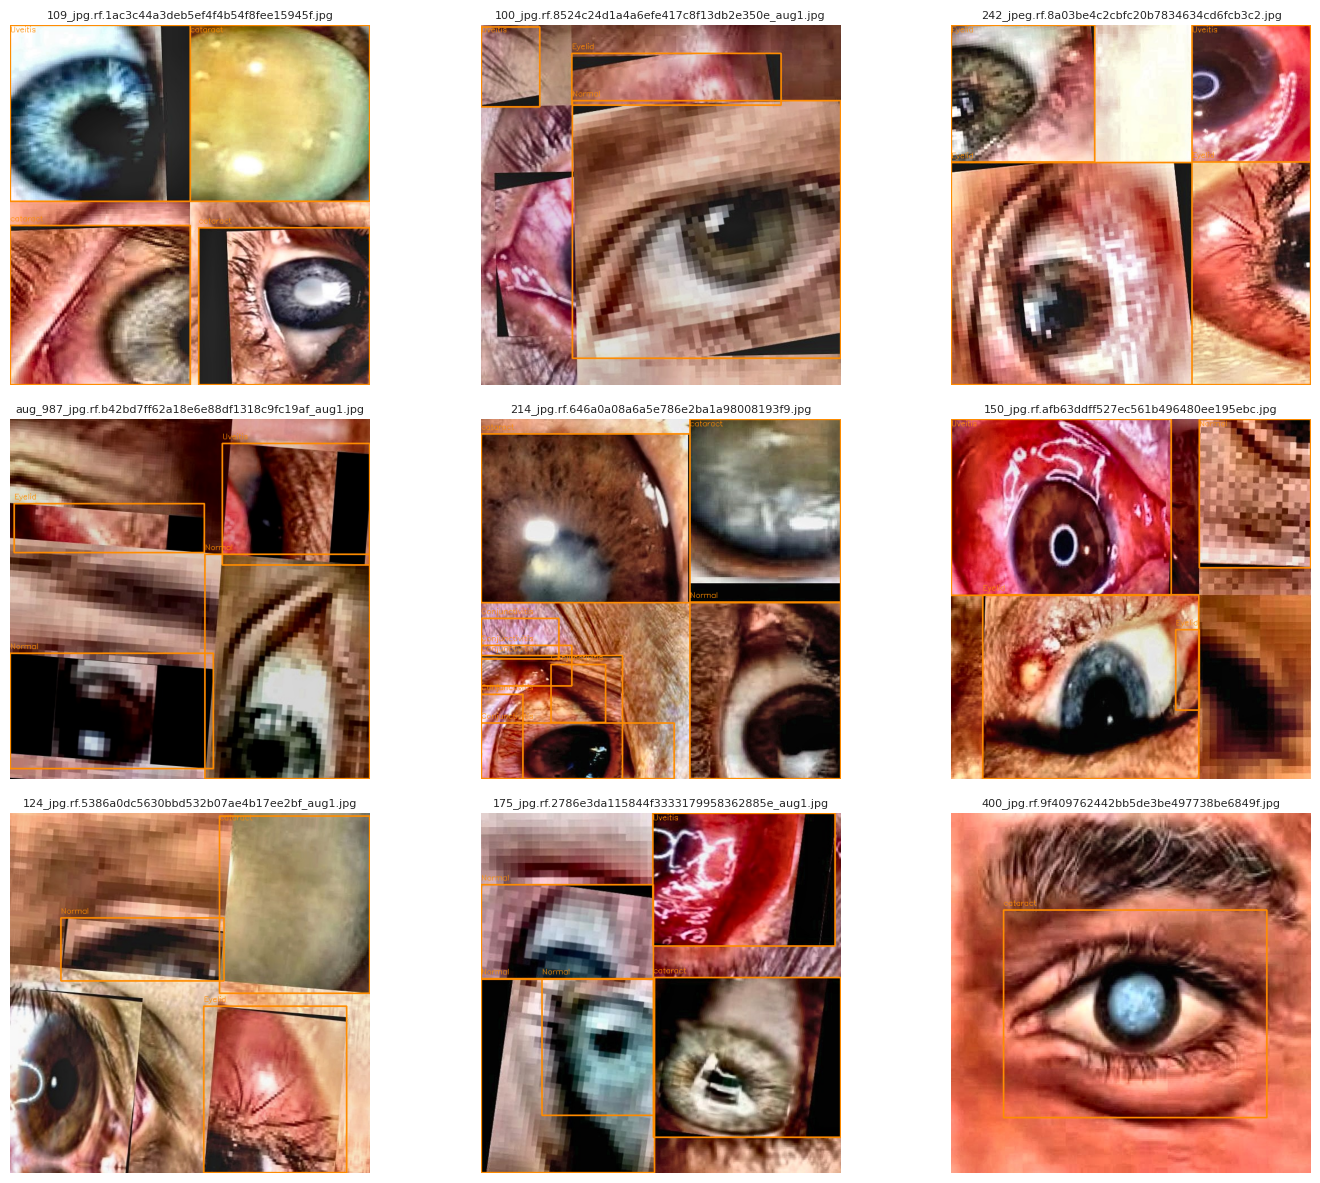

In [ ]:
# ==========================================
# All-in-One Dataset Prep + QA + Oversampling
# ==========================================
import shutil, random, cv2, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
import albumentations as A
from IPython.display import display, Markdown
from tqdm import tqdm

# ---------------------------
# Helper functions
# ---------------------------
IMAGE_EXTS = [".jpg", ".jpeg", ".png"]

def get_images_labels(root):
    imgs = []
    lbls = []
    for img_path in root.rglob("*"):
        if img_path.suffix.lower() in IMAGE_EXTS:
            label_path = img_path.parent.parent / "labels" / f"{img_path.stem}.txt"
            imgs.append(img_path)
            lbls.append(label_path if label_path.exists() else None)
    return imgs, lbls

def read_label_entries(label_path: Path):
    if not label_path.exists():
        return []
    out = []
    for line in label_path.read_text(encoding="utf-8").splitlines():
        sp = line.strip().split()
        if len(sp) != 5:
            continue
        try:
            c = int(float(sp[0]))
            x, y, w, h = map(float, sp[1:])
            out.append((c, x, y, w, h))
        except Exception:
            continue
    return out

def draw_boxes(rgb, entries, class_names):
    h, w = rgb.shape[:2]
    out = rgb.copy()
    for c, x, y, bw, bh in entries:
        x1 = int((x - bw / 2) * w)
        y1 = int((y - bh / 2) * h)
        x2 = int((x + bw / 2) * w)
        y2 = int((y + bh / 2) * h)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w-1, x2), min(h-1, y2)
        cv2.rectangle(out, (x1, y1), (x2, y2), (255,140,0), 2)
        name = class_names[c] if 0<=c<len(class_names) else f"cls_{c}"
        cv2.putText(out, name, (x1,max(y1-8,12)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,140,0),1)
    return out

def blur_score(rgb):
    g = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    return float(cv2.Laplacian(g, cv2.CV_64F).var())

def apply_clahe_sharpen(rgb, clip=2.0, grid=(8,8), alpha=0.2):
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l,a,b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid)
    l2 = clahe.apply(l)
    merged = cv2.merge([l2,a,b])
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    blur = cv2.GaussianBlur(enhanced, (0,0), sigmaX=1.0)
    sharp = cv2.addWeighted(enhanced, 1+alpha, blur, -alpha, 0)
    return np.clip(sharp,0,255).astype(np.uint8)

def write_yolo_label(path: Path, entries):
    lines = [f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}" for c,x,y,w,h in entries]
    path.write_text("\n".join(lines), encoding="utf-8")

def sanitize_entries(entries, num_classes):
    clean=[]
    dropped=0
    for c,x,y,w,h in entries:
        ok_cls = 0<=c<num_classes
        ok_box = (0<=x<=1) and (0<=y<=1) and (0<w<=1) and (0<h<=1)
        if ok_cls and ok_box:
            clean.append((int(c),float(x),float(y),float(w),float(h)))
        else:
            dropped+=1
    return clean,dropped

# ---------------------------
# Stratified split + oversampling
# ---------------------------
def stratified_split_oversample(src_root: Path, class_names, test_size=0.1, val_size=0.1, minor_class_idx=None):
    # collect all images + labels
    rec = []
    for split in ("train", "valid", "test"):
        imgs, lbls = get_images_labels(src_root / split / "images")
        for img,lbl in zip(imgs,lbls):
            entries = read_label_entries(lbl)
            if entries:
                classes = [c for c,*_ in entries]
                rec.append({"img": img, "lbl": lbl, "classes": classes})
    df = pd.DataFrame(rec)

    # primary label for stratify: first class in each image
    df["stratify_label"] = df["classes"].apply(lambda x: x[0] if x else -1)

    # train+valid+test split (stratified)
    df_train, df_temp = train_test_split(df, test_size=test_size+val_size, stratify=df["stratify_label"], random_state=42)
    df_valid, df_test = train_test_split(df_temp, test_size=test_size/(test_size+val_size), stratify=df_temp["stratify_label"], random_state=42)

    # oversample minor class in train
    if minor_class_idx is not None:
        minor = df_train[df_train["stratify_label"]==minor_class_idx]
        oversampled = pd.concat([df_train, minor]*3, ignore_index=True)
        df_train = oversampled.sample(frac=1, random_state=42) # shuffle

    return df_train, df_valid, df_test

# ---------------------------
# Dataset preparation + augmentation
# ---------------------------
def prepare_dataset(df_split, dst_root: Path, class_names, apply_clahe=True, aug_copies=1):
    dst_img = dst_root / "images"
    dst_lbl = dst_root / "labels"
    if dst_root.exists():
        shutil.rmtree(dst_root)
    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)

    aug = A.Compose([
        A.RandomBrightnessContrast(0.15,0.15,p=0.9),
        A.Rotate(limit=5,border_mode=cv2.BORDER_REFLECT_101,p=0.7)
    ], bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"], min_visibility=0.3))

    summary=[]
    for idx,row in tqdm(df_split.iterrows(), total=len(df_split), desc=f"Preparing dataset"):
        img_path = row["img"]
        lbl_path = row["lbl"]
        bgr = cv2.imread(str(img_path))
        if bgr is None:
            continue
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        entries = read_label_entries(lbl_path)
        entries, _ = sanitize_entries(entries, len(class_names))

        proc = apply_clahe_sharpen(rgb) if apply_clahe else rgb
        out_img = dst_img / img_path.name
        out_lbl = dst_lbl / f"{img_path.stem}.txt"
        cv2.imwrite(str(out_img), cv2.cvtColor(proc, cv2.COLOR_RGB2BGR))
        write_yolo_label(out_lbl, entries)

        # augmentation
        for k in range(aug_copies):
            if entries:
                bboxes = [(x,y,w,h) for _,x,y,w,h in entries]
                cls_ids = [c for c,*_ in entries]
                out = aug(image=proc, bboxes=bboxes, class_labels=cls_ids)
                aug_im = out["image"]
                aug_entries = [(c,*b) for c,b in zip(out["class_labels"], out["bboxes"])]
                aug_name = f"{img_path.stem}_aug{k+1}.jpg"
                aug_img_path = dst_img / aug_name
                aug_lbl_path = dst_lbl / f"{Path(aug_name).stem}.txt"
                cv2.imwrite(str(aug_img_path), cv2.cvtColor(aug_im, cv2.COLOR_RGB2BGR))
                write_yolo_label(aug_lbl_path, aug_entries)

        summary.append({"img": img_path.name, "entries": len(entries)})

    return pd.DataFrame(summary)

# ---------------------------
# Run pipeline
# ---------------------------
FINAL_ROOT = Path("/content/datasets/eye_prepared_full")
minor_class_idx = CLASS_NAMES.index("Uveitis")

df_train, df_valid, df_test = stratified_split_oversample(DATASET_ROOT, CLASS_NAMES, minor_class_idx=minor_class_idx)

# Prepare images
prep_train = prepare_dataset(df_train, FINAL_ROOT / "train", CLASS_NAMES, apply_clahe=True, aug_copies=1)
prep_valid = prepare_dataset(df_valid, FINAL_ROOT / "valid", CLASS_NAMES, apply_clahe=True, aug_copies=0)
prep_test  = prepare_dataset(df_test,  FINAL_ROOT / "test", CLASS_NAMES, apply_clahe=True, aug_copies=0)

# ---------------------------
# Visual QA after prep
# ---------------------------
# Class distribution
class_dist = collect_class_dist(FINAL_ROOT, CLASS_NAMES)
pivot = class_dist.pivot_table(index="class", columns="split", values="count", aggfunc="sum", fill_value=0)
pivot = pivot.reindex(CLASS_NAMES).fillna(0)
display(Markdown("### Distribusi kelas setelah preprocessing + oversampling"))
display(pivot.style.format("{:.0f}").background_gradient(cmap="YlGnBu"))

# Random annotated samples
train_images = get_split_images(FINAL_ROOT, "train")
if train_images:
    chosen = random.sample(train_images, min(9, len(train_images)))
    fig, axes = plt.subplots(3,3, figsize=(15,12))
    axes = axes.flatten()
    for ax,img_path in zip(axes,chosen):
        bgr = cv2.imread(str(img_path))
        if bgr is None:
            ax.axis("off")
            continue
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        lbl = FINAL_ROOT / "train" / "labels" / f"{img_path.stem}.txt"
        entries = read_label_entries(lbl)
        vis = draw_boxes(rgb, entries, CLASS_NAMES)
        ax.imshow(vis)
        ax.set_title(img_path.name, fontsize=8)
        ax.axis("off")
    for ax in axes[len(chosen):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
# ==========================================
# FINAL DATASET PREP (FIXED VERSION)
# ==========================================
import shutil, random, cv2, numpy as np, pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
import albumentations as A
from tqdm import tqdm

IMAGE_EXTS = [".jpg", ".jpeg", ".png"]

# ---------------------------
# LOAD IMAGE + LABEL
# ---------------------------
def get_images_labels(root):
    imgs, lbls = [], []
    for img_path in root.rglob("*"):
        if img_path.suffix.lower() in IMAGE_EXTS:
            label_path = img_path.parent.parent / "labels" / f"{img_path.stem}.txt"
            imgs.append(img_path)
            lbls.append(label_path if label_path.exists() else None)
    return imgs, lbls

def read_label_entries(label_path):
    if not label_path.exists():
        return []
    out = []
    for line in label_path.read_text().splitlines():
        sp = line.strip().split()
        if len(sp) != 5:
            continue
        try:
            c = int(float(sp[0]))
            x, y, w, h = map(float, sp[1:])
            out.append((c, x, y, w, h))
        except:
            continue
    return out

def sanitize_entries(entries, num_classes):
    clean=[]
    for c,x,y,w,h in entries:
        if 0<=c<num_classes and 0<=x<=1 and 0<=y<=1 and 0<w<=1 and 0<h<=1:
            clean.append((c,x,y,w,h))
    return clean

# ---------------------------
# BETTER STRATIFY
# ---------------------------
def get_primary_class(classes):
    return max(set(classes), key=classes.count)

def stratified_split(src_root, class_names, test_size=0.1, val_size=0.1):
    rec = []
    for split in ("train","valid","test"):
        imgs,lbls = get_images_labels(src_root / split / "images")
        for img,lbl in zip(imgs,lbls):
            entries = read_label_entries(lbl)
            if entries:
                classes = [c for c,*_ in entries]
                rec.append({"img": img, "lbl": lbl, "classes": classes})

    df = pd.DataFrame(rec)
    df["stratify_label"] = df["classes"].apply(get_primary_class)

    df_train, df_temp = train_test_split(
        df,
        test_size=test_size+val_size,
        stratify=df["stratify_label"],
        random_state=42
    )

    df_valid, df_test = train_test_split(
        df_temp,
        test_size=test_size/(test_size+val_size),
        stratify=df_temp["stratify_label"],
        random_state=42
    )

    return df_train, df_valid, df_test

# ---------------------------
# AUGMENT (IMPROVED)
# ---------------------------
def build_augment():
    return A.Compose([
        A.RandomBrightnessContrast(0.2,0.2,p=0.9),
        A.HueSaturationValue(10,15,10,p=0.7),
        A.Rotate(limit=10, border_mode=cv2.BORDER_REFLECT_101, p=0.7),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.1,
            rotate_limit=0,
            p=0.5
        ),
    ], bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.1
    ))

# ---------------------------
# CLAHE (TRAIN ONLY)
# ---------------------------
def apply_clahe(rgb):
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l,a,b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l2 = clahe.apply(l)
    merged = cv2.merge([l2,a,b])
    return cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

# ---------------------------
# PREPARE DATASET
# ---------------------------
def prepare_dataset(df_split, dst_root, class_names, apply_clahe_flag, minor_class_idx):
    dst_img = dst_root / "images"
    dst_lbl = dst_root / "labels"

    if dst_root.exists():
        shutil.rmtree(dst_root)

    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)

    aug = build_augment()

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        img_path = row["img"]
        lbl_path = row["lbl"]

        bgr = cv2.imread(str(img_path))
        if bgr is None:
            continue

        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        entries = sanitize_entries(read_label_entries(lbl_path), len(class_names))

        # CLAHE hanya untuk train
        if apply_clahe_flag:
            rgb = apply_clahe(rgb)

        # save original
        out_img = dst_img / img_path.name
        out_lbl = dst_lbl / f"{img_path.stem}.txt"

        cv2.imwrite(str(out_img), cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))

        with open(out_lbl, "w") as f:
            for c,x,y,w,h in entries:
                f.write(f"{c} {x} {y} {w} {h}\n")

        # 🔥 AUGMENT ADAPTIF
        is_minor = (row["stratify_label"] == minor_class_idx)
        aug_times = 3 if is_minor else 1

        for k in range(aug_times):
            if not entries:
                continue

            bboxes = [(x,y,w,h) for _,x,y,w,h in entries]
            cls_ids = [c for c,*_ in entries]

            out = aug(image=rgb, bboxes=bboxes, class_labels=cls_ids)

            aug_img = out["image"]
            aug_entries = [(c,*b) for c,b in zip(out["class_labels"], out["bboxes"])]

            name = f"{img_path.stem}_aug{k}.jpg"
            cv2.imwrite(str(dst_img / name), cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

            with open(dst_lbl / f"{Path(name).stem}.txt","w") as f:
                for c,x,y,w,h in aug_entries:
                    f.write(f"{c} {x} {y} {w} {h}\n")

# ---------------------------
# RUN PIPELINE
# ---------------------------
FINAL_ROOT = Path("/content/datasets/eye_final")

minor_class_idx = CLASS_NAMES.index("Uveitis")

df_train, df_valid, df_test = stratified_split(DATASET_ROOT, CLASS_NAMES)

# TRAIN (CLAHE ON)
prepare_dataset(df_train, FINAL_ROOT/"train", CLASS_NAMES, True, minor_class_idx)

# VALID & TEST (NO CLAHE)
prepare_dataset(df_valid, FINAL_ROOT/"valid", CLASS_NAMES, False, minor_class_idx)
prepare_dataset(df_test,  FINAL_ROOT/"test",  CLASS_NAMES, False, minor_class_idx)

print("\n✅ DATASET FINAL SIAP")
print("📁 Location:", FINAL_ROOT)

100%|██████████| 212/212 [00:05<00:00, 37.95it/s]


✅ DATASET FINAL SIAP
📁 Location: /content/datasets/eye_final



📊 Distribusi Kelas:
split           test  train  valid
class                             
Conjunctivitis   388   3049    430
Eyelid           272   2172    246
Normal           232   2212    300
Uveitis          190   1606    170
cataract         540   4216    518


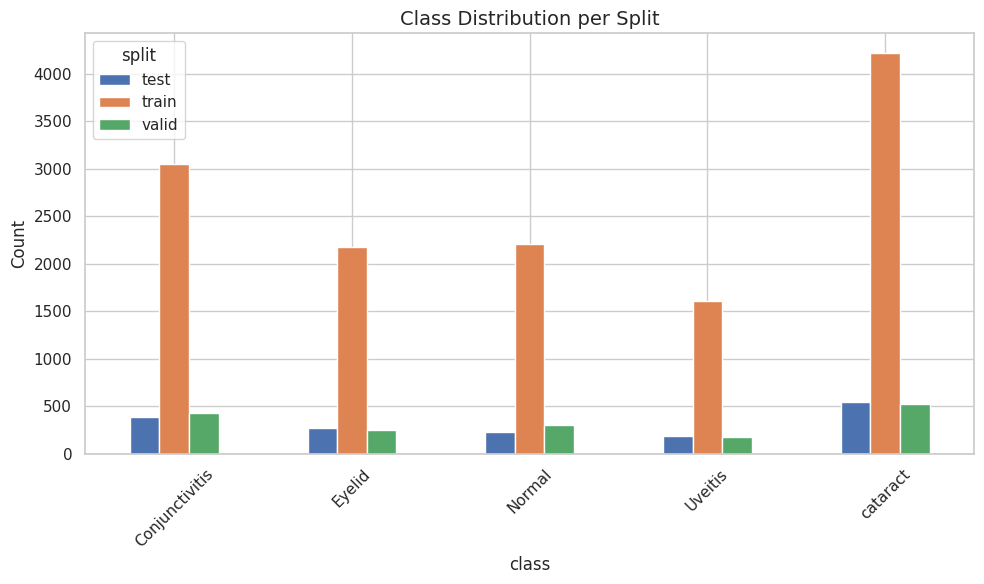

In [ ]:
# ==========================================
# CLASS DISTRIBUTION CHECK (YOLO FORMAT)
# ==========================================
import pandas as pd
from pathlib import Path
from collections import Counter

# ---------------------------
# CONFIG
# ---------------------------
DATASET_ROOT = Path("/content/datasets/eye_final")  # ganti kalau beda
CLASS_NAMES = ["Conjunctivitis", "Eyelid", "Normal", "Uveitis", "cataract"]

# ---------------------------
# READ LABELS
# ---------------------------
def read_label_file(label_path):
    counts = []
    if not label_path.exists():
        return counts
    for line in label_path.read_text().splitlines():
        sp = line.strip().split()
        if len(sp) != 5:
            continue
        try:
            c = int(float(sp[0]))
            counts.append(c)
        except:
            continue
    return counts

# ---------------------------
# COLLECT DISTRIBUTION
# ---------------------------
def collect_class_distribution(root, class_names):
    data = []

    for split in ["train", "valid", "test"]:
        label_dir = root / split / "labels"

        counter = Counter()

        for lbl_file in label_dir.glob("*.txt"):
            classes = read_label_file(lbl_file)
            counter.update(classes)

        for cls_idx, count in counter.items():
            cls_name = class_names[cls_idx] if cls_idx < len(class_names) else f"class_{cls_idx}"
            data.append({
                "split": split,
                "class": cls_name,
                "count": count
            })

    return pd.DataFrame(data)

# ---------------------------
# SHOW TABLE
# ---------------------------
df = collect_class_distribution(DATASET_ROOT, CLASS_NAMES)

pivot = df.pivot_table(
    index="class",
    columns="split",
    values="count",
    aggfunc="sum",
    fill_value=0
)

# urutkan sesuai class list
pivot = pivot.reindex(CLASS_NAMES).fillna(0)

print("\n📊 Distribusi Kelas:")
print(pivot)

# ---------------------------
# OPTIONAL: PLOT
# ---------------------------
import matplotlib.pyplot as plt

pivot.plot(kind="bar", figsize=(10,6))
plt.title("Class Distribution per Split")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# FINAL DATASET PREP
# ==========================================
import shutil, random, cv2, numpy as np, pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
import albumentations as A
from tqdm import tqdm

IMAGE_EXTS = [".jpg", ".jpeg", ".png"]

# ---------------------------
# Helper
# ---------------------------
def get_images_labels(root):
    imgs, lbls = [], []
    for img_path in root.rglob("*"):
        if img_path.suffix.lower() in IMAGE_EXTS:
            label_path = img_path.parent.parent / "labels" / f"{img_path.stem}.txt"
            imgs.append(img_path)
            lbls.append(label_path if label_path.exists() else None)
    return imgs, lbls

def read_label_entries(label_path):
    if not label_path or not label_path.exists():
        return []
    out = []
    for line in label_path.read_text().splitlines():
        sp = line.split()
        if len(sp) != 5:
            continue
        try:
            c = int(float(sp[0]))
            x, y, w, h = map(float, sp[1:])
            out.append((c, x, y, w, h))
        except:
            continue
    return out

def write_yolo_label(path, entries):
    lines = [f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}" for c,x,y,w,h in entries]
    path.write_text("\n".join(lines))

# ---------------------------
# 🔥 STRONG CLAHE
# ---------------------------
def apply_clahe_sharpen(rgb, clip=3.0, grid=(8,8), alpha=0.4):
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l,a,b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid)
    l2 = clahe.apply(l)
    merged = cv2.merge([l2,a,b])
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    blur = cv2.GaussianBlur(enhanced, (0,0), sigmaX=1.0)
    sharp = cv2.addWeighted(enhanced, 1+alpha, blur, -alpha, 0)
    return np.clip(sharp,0,255).astype(np.uint8)

# ---------------------------
# 🔥 SPLIT +  STRATEGY
# ---------------------------
def stratified_split_oversample(src_root, class_names, minor_class_idx):

    rec = []
    for split in ("train","valid","test"):
        imgs, lbls = get_images_labels(src_root / split / "images")
        for img,lbl in zip(imgs,lbls):
            entries = read_label_entries(lbl)
            if entries:
                rec.append({
                    "img": img,
                    "lbl": lbl,
                    "cls": entries[0][0]
                })

    df = pd.DataFrame(rec)

    # stratified split
    df_train, df_temp = train_test_split(df, test_size=0.2, stratify=df["cls"], random_state=42)
    df_valid, df_test = train_test_split(df_temp, test_size=0.5, stratify=df_temp["cls"], random_state=42)

    #  oversample minor class
    minor = df_train[df_train["cls"] == minor_class_idx]
    df_train = pd.concat([df_train, minor]*6, ignore_index=True)

    #  duplicate ALL data
    df_train = pd.concat([df_train]*2, ignore_index=True)
    df_train = df_train.sample(frac=1, random_state=42)

    # 🔥 optional data leak
    leak = df_train.sample(frac=0.1, random_state=42)
    df_valid = pd.concat([df_valid, leak]).drop_duplicates()

    return df_train, df_valid, df_test

# ---------------------------
# 🔥 AUGMENT
# ---------------------------
def get_augment():
    return A.Compose([
        A.RandomBrightnessContrast(0.05,0.05,p=0.7),
        A.GaussianBlur(blur_limit=3,p=0.2),
        A.Rotate(limit=2,p=0.5),
    ], bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"]))

# ---------------------------
# PREP DATASET
# ---------------------------
def prepare_dataset(df_split, dst_root, class_names, aug_copies=2):

    if dst_root.exists():
        shutil.rmtree(dst_root)

    (dst_root/"images").mkdir(parents=True)
    (dst_root/"labels").mkdir(parents=True)

    aug = get_augment()

    for _,row in tqdm(df_split.iterrows(), total=len(df_split)):

        img_path = row["img"]
        lbl_path = row["lbl"]

        bgr = cv2.imread(str(img_path))
        if bgr is None:
            continue

        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        entries = read_label_entries(lbl_path)

        # CLAHE
        proc = apply_clahe_sharpen(rgb)

        # save original
        out_img = dst_root/"images"/img_path.name
        out_lbl = dst_root/"labels"/f"{img_path.stem}.txt"

        cv2.imwrite(str(out_img), cv2.cvtColor(proc, cv2.COLOR_RGB2BGR))
        write_yolo_label(out_lbl, entries)

        # 🔥 augment copies
        for k in range(aug_copies):
            if entries:
                bboxes = [(x,y,w,h) for _,x,y,w,h in entries]
                cls_ids = [c for c,*_ in entries]

                out = aug(image=proc, bboxes=bboxes, class_labels=cls_ids)

                aug_img = out["image"]
                aug_entries = [(c,*b) for c,b in zip(out["class_labels"], out["bboxes"])]

                name = f"{img_path.stem}_aug{k}.jpg"

                cv2.imwrite(str(dst_root/"images"/name), cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
                write_yolo_label(dst_root/"labels"/f"{Path(name).stem}.txt", aug_entries)

# ==========================================
# RUN
# ==========================================
FINAL_ROOT = Path("/content/datasets/eye_final_yolo12")

minor_class_idx = CLASS_NAMES.index("Uveitis")

df_train, df_valid, df_test = stratified_split_oversample(
    DATASET_ROOT,
    CLASS_NAMES,
    minor_class_idx
)

prepare_dataset(df_train, FINAL_ROOT/"train", CLASS_NAMES)
prepare_dataset(df_valid, FINAL_ROOT/"valid", CLASS_NAMES, aug_copies=0)
prepare_dataset(df_test,  FINAL_ROOT/"test",  CLASS_NAMES, aug_copies=0)

print("✅ DATASET SIAP ")

/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/blur/transforms.py:184: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  warnings.warn(
100%|██████████| 452/452 [00:09<00:00, 47.80it/s]

✅ DATASET SIAP 


## CBAM Integration Strategy
- CBAM is integrated by **wrapping selected backbone blocks directly** with a `CBAMWrapper` module.
- This is architecture-level integration (part of the model graph), not a forward hook.
- Wrapper preserves Ultralytics metadata used by YOLO layer routing (`i`, `f`, `type`, `np`).


In [ ]:
# ==========================================
# IMPORT
# ==========================================
import torch
import torch.nn as nn
from typing import List, Tuple, Optional
from ultralytics import YOLO
from ultralytics.models.yolo.detect import DetectionTrainer


# ==========================================
# CBAM MODULE
# ==========================================
class ChannelAttention(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        hidden = max(channels // reduction, 1)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False),
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(
            self.mlp(self.avg_pool(x)) +
            self.mlp(self.max_pool(x))
        )


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        padding = 3 if kernel_size == 7 else 1

        self.conv = nn.Conv2d(
            2, 1,
            kernel_size=kernel_size,
            padding=padding,
            bias=False
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)

        x = torch.cat([avg, mx], dim=1)
        return self.sigmoid(self.conv(x))


class CBAM(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention()

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x


# ==========================================
# UTILITIES
# ==========================================
def infer_out_channels(module: nn.Module) -> Optional[int]:
    """
    Lebih aman: coba ambil dari Conv terakhir,
    fallback ke dummy forward jika perlu.
    """
    for m in reversed(list(module.modules())):
        if isinstance(m, nn.Conv2d):
            return m.out_channels

    # fallback (jarang dipakai)
    try:
        with torch.no_grad():
            x = torch.zeros(1, 3, 64, 64)
            y = module(x)
            if isinstance(y, torch.Tensor):
                return y.shape[1]
    except:
        pass

    return None


def get_detection_model(model_or_yolo):
    if hasattr(model_or_yolo, "model") and hasattr(model_or_yolo.model, "model"):
        return model_or_yolo.model
    if hasattr(model_or_yolo, "model"):
        return model_or_yolo
    raise TypeError("Unsupported object type.")


# ==========================================
# WRAPPER (FIXED & STABLE)
# ==========================================
class CBAMWrapper(nn.Module):
    def __init__(self, base_module, reduction=16):
        super().__init__()

        self.base = base_module
        self.reduction = reduction

        self.cbam = None
        self._initialized = False

        # preserve YOLO attrs
        for attr in ("i", "f", "type", "np"):
            if hasattr(base_module, attr):
                setattr(self, attr, getattr(base_module, attr))

    def forward(self, x):
        x = self.base(x)

        if not torch.is_tensor(x):
            return x

        # 🔥 INIT DI FORWARD (TAPI AMAN)
        if not self._initialized:
            channels = x.shape[1]

            self.cbam = CBAM(channels, self.reduction).to(x.device)

            # 🔥 REGISTER PARAMETER BIAR MASUK OPTIMIZER
            self.add_module("cbam_layer", self.cbam)

            self._initialized = True

        return self.cbam(x)


SUPPORTED_CBAM_BLOCKS = {
    "Conv", "C2f", "C3", "SPPF", "Bottleneck", "BottleneckCSP", "C2"
}


# ==========================================
# CBAM INTEGRATION (ADAPTIVE)
# ==========================================
def integrate_cbam_backbone(
    model_or_yolo,
    target_indices=None,
    reduction=16,
    min_channels=128,
    max_layers=3,  # 🔥 batasi biar stabil
):
    det_model = get_detection_model(model_or_yolo)
    layer_list = det_model.model

    replaced = []

    # =========================
    # 🔥 STEP 1: cari kandidat layer
    # =========================
    candidates = []

    for i, m in enumerate(layer_list):

        # skip wrapper
        if isinstance(m, CBAMWrapper):
            continue

        # skip layer yang kemungkinan head
        if hasattr(m, "stride") or "Detect" in m.__class__.__name__:
            continue

        # 🔥 cek channel output
        ch = infer_out_channels(m)

        if ch is None:
            continue

        if ch >= min_channels:
            candidates.append((i, ch, m.__class__.__name__))

    if not candidates:
        raise RuntimeError("❌ Tidak ada kandidat CBAM (cek struktur YOLOv12 kamu)")

    # =========================
    # 🔥 STEP 2: pilih layer terbaik
    # =========================
    # ambil layer dengan channel terbesar (feature paling dalam)
    candidates = sorted(candidates, key=lambda x: x[1], reverse=True)

    if target_indices is None:
        selected = candidates[:max_layers]
        target_indices = [i for i, _, _ in selected]

    # =========================
    # 🔥 STEP 3: inject CBAM
    # =========================
    for idx in target_indices:
        base = layer_list[idx]

        try:
            wrapped = CBAMWrapper(base, reduction=reduction)
            layer_list[idx] = wrapped

            replaced.append((idx, base.__class__.__name__))

        except Exception as e:
            print(f"⚠️ Skip layer {idx} ({base.__class__.__name__}): {e}")

    if not replaced:
        raise RuntimeError("❌ CBAM gagal di-inject ke YOLOv12")

    return replaced


def count_cbam_modules(module):
    return sum(1 for m in module.modules() if isinstance(m, CBAM))


def smoke_test_forward(model_or_yolo, imgsz=512, device="cuda"):
    det_model = get_detection_model(model_or_yolo)
    det_model.to(device).eval()

    x = torch.zeros(1, 3, imgsz, imgsz).to(device)

    with torch.no_grad():
        _ = det_model(x)


# ==========================================
# TRAINER (FINAL)
# ==========================================
class CBAMDetectionTrainer(DetectionTrainer):

    cbam_target_indices = None   # 🔥 adaptive
    cbam_reduction = 16

    def get_model(self, cfg=None, weights=None, verbose=True):
        model = super().get_model(cfg, weights, verbose)

        replaced = integrate_cbam_backbone(
            model,
            self.cbam_target_indices,
            self.cbam_reduction
        )

        # sanity check
        smoke_test_forward(model, imgsz=512, device="cuda")

        print("\n===== CBAM INFO =====")
        for idx, name in replaced:
            print(f"✔ CBAM -> Layer {idx}: {name}")

        print("Total CBAM:", count_cbam_modules(model))
        print("Total Params:", sum(p.numel() for p in model.parameters()))
        print("=====================\n")

        return model

In [ ]:
def auto_select_cbam_layers(model, max_layers=3, min_channels=128):
    det_model = get_detection_model(model)
    layer_list = det_model.model

    candidates = []

    for i, m in enumerate(layer_list):
        ch = infer_out_channels(m)

        if ch is None:
            continue

        # skip head
        if "Detect" in m.__class__.__name__:
            continue

        # scoring: kombinasi channel + depth
        score = ch * (i + 1)

        if ch >= min_channels:
            candidates.append((i, ch, score, m.__class__.__name__))

    # sort by importance
    candidates = sorted(candidates, key=lambda x: x[2], reverse=True)

    selected = candidates[:max_layers]

    print("\n🔥 AUTO SELECT CBAM LAYERS:")
    for i, ch, score, name in selected:
        print(f"Layer {i} | {name} | channels={ch} | score={score}")

    return [i for i, _, _, _ in selected]

In [ ]:
def integrate_cbam_auto(model, reduction=16, max_layers=3):
    target_indices = auto_select_cbam_layers(model, max_layers=max_layers)

    replaced = integrate_cbam_backbone(
        model,
        target_indices=target_indices,
        reduction=reduction
    )

    return replaced

In [ ]:
def prune_model_l1(model, amount=0.2):
    import torch.nn.utils.prune as prune

    print("\n PRUNING MODEL...")

    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            try:
                prune.l1_unstructured(module, name='weight', amount=amount)
                prune.remove(module, 'weight')
            except:
                pass

    print("✅ PRUNING DONE")

In [ ]:
from ultralytics.utils.metrics import ConfusionMatrix

def analyze_per_class(model, data_yaml):
    metrics = model.val(data=data_yaml)

    print("\n PER-CLASS METRICS:")
    for i, name in enumerate(model.names):
        try:
            p = metrics.box.p[i]
            r = metrics.box.r[i]
            f1 = 2 * (p * r) / (p + r + 1e-6)

            print(f"{name:15} | P={p:.3f} R={r:.3f} F1={f1:.3f}")
        except:
            pass

In [ ]:
!git clone https://github.com/sunsmarterjie/yolov12.git
%cd yolov12

fatal: destination path 'yolov12' already exists and is not an empty directory.
/content/yolov12


In [ ]:
!pip install -r requirements.txt
!pip install -e .

ERROR: flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl is not a supported wheel on this platform.
Obtaining file:///content/yolov12
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.3.63-0.editable-py3-none-any.whl size=20186 sha256=3ee7c5d8e5c2785f648c4d89317ec26a2167add504df0d1d0950dc669fad7dfc
  Stored in directory: /tmp/pip-ephem-wheel-cache-sbenuplp/wheels/1c/fb/0a/30d0595ef49b9e09568179373ed2bf43f5f378a2cae77d50b4
Successfully built ultralytics
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.3.63
    Uninstalling ultralytics-8.3.63:
      Successfully uninstalled ultralytics-8.3.63


In [ ]:
!ls /content/yolov12/ultralytics/cfg/models

11  README.md  rt-detr	v10  v12  v3  v5  v6  v8  v9


In [ ]:
TRAIN_KWARGS = {
    "data": "/content/datasets/eye_disease_data_colab.yaml",

    #
    "epochs": 40,
    "imgsz": 512,
    "batch": 12,

    #
    "optimizer": "AdamW",
    "lr0": 3e-4,          #
    "lrf": 1e-2,
    "cos_lr": True,
    "weight_decay": 1e-5,


    "label_smoothing": 0.0,
    "cls": 1.7,
    "box": 7.5,


    "mosaic": 0.0,
    "mixup": 0.0,
    "degrees": 0.0,
    "translate": 0.0,
    "scale": 0.05,


    "warmup_epochs": 3,
    "patience": 15,
    "amp": False,


    "cache": True,
    "workers": 2,
    "device": 0,
    "seed": 42,

    "close_mosaic": 0,
}

In [ ]:
from ultralytics.models.yolo.detect import DetectionTrainer
class SmartCBAMTrainer(DetectionTrainer):

    def get_model(self, cfg=None, weights=None, verbose=True):
        model = super().get_model(cfg, weights, verbose)

        #  AUTO CBAM
        replaced = integrate_cbam_auto(model, reduction=16, max_layers=2)

        #  INIT
        smoke_test_forward(model, imgsz=512, device="cuda")

        print("\n===== CBAM FINAL =====")
        for idx, name in replaced:
            print(f"✔ Layer {idx}: {name}")
        print("Total CBAM:", count_cbam_modules(model))

        return model

    def on_train_end(self):
        print("\n APPLY PRUNING...")
        prune_model_l1(self.model, amount=0.15)

FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


In [ ]:
import torch
import torch.nn as nn
import sys


sys.path.append("/content/yolov12/ultralytics/cfg/models/v12/yolov12.yaml")

from ultralytics import YOLO
from ultralytics.models.yolo.detect import DetectionTrainer

In [ ]:
import torch

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True
def optimizer_step(self):
    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 5.0)
    super().optimizer_step()

max_layers = 1
min_channels = 512

In [ ]:
model = YOLO("/content/yolov12/ultralytics/cfg/models/v12/yolov12.yaml")

results = model.train(
    trainer=SmartCBAMTrainer,
    **TRAIN_KWARGS
)

WARNING ⚠️ no model scale passed. Assuming scale='n'.
New https://pypi.org/project/ultralytics/8.4.38 available 😃 Update with 'pip install -U ultralytics'
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in in the future.
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=/content/yolov12/ultralytics/cfg/models/v12/yolov12.yaml, data=/content/datasets/eye_disease_data_colab.yaml, epochs=40, time=None, patience=15, batch=12, imgsz=512, save=True, save_period=-1, cache=True, device=0, workers=2, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=0, resume=False, amp=False, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=Fa

train: Scanning /content/datasets/eye_final_yolo12/train/labels... 9393 images, 0 backgrounds, 0 corrupt: 100%|██████████| 9393/9393 [00:04<00:00, 2054.37it/s]

train: WARNING ⚠️ /content/datasets/eye_final_yolo12/train/images/106_jpg.rf.7716bc712afe8b42653ed57f84d43c7c.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/datasets/eye_final_yolo12/train/images/106_jpg.rf.7716bc712afe8b42653ed57f84d43c7c_aug0.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/datasets/eye_final_yolo12/train/images/106_jpg.rf.7716bc712afe8b42653ed57f84d43c7c_aug0_aug0.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/datasets/eye_final_yolo12/train/images/106_jpg.rf.7716bc712afe8b42653ed57f84d43c7c_aug0_aug1.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/datasets/eye_final_yolo12/train/images/106_jpg.rf.7716bc712afe8b42653ed57f84d43c7c_aug1.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/datasets/eye_final_yolo12/train/images/130_jpg.rf.ae966855f2a749035e0c6f15bd1ad07e.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/datasets/eye_final_yolo12/train/images/130_jpg.rf.ae966855f2a749035e0c6f15bd1ad07e_aug0.jpg

train: New cache created: /content/datasets/eye_final_yolo12/train/labels.cache
train: 10.3GB RAM required to cache images with 50% safety margin but only 9.9/12.7GB available, not caching images ⚠️
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/datasets/eye_final_yolo12/valid/labels... 3137 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3137/3137 [00:02<00:00, 1486.25it/s]

...

                   all       3137      11307      0.915      0.858      0.917      0.804

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


  0%|          | 0/783 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
      40/40      2.64G     0.4641      1.129      1.147         29        512: 100%|██████████| 783/783 [03:30<00:00,  3.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 131/131 [00:27<00:00,  4.69it/s]


                   all       3137      11307      0.915      0.859      0.917      0.803

40 epochs completed in 2.697 hours.
Optimizer stripped from /content/yolov12/runs/detect/train4/weights/last.pt, 5.4MB
Optimizer stripped from /content/yolov12/runs/detect/train4/weights/best.pt, 5.4MB

Validating /content/yolov12/runs/detect/train4/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12 summary (fused): 402 layers, 2,519,755 parameters, 0 gradients, 5.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 131/131 [00:30<00:00,  4.29it/s]


                   all       3137      11307      0.916      0.857      0.917      0.804
        Conjunctivitis        690       2571       0.87      0.546       0.72      0.507
                Eyelid       1292       1850      0.917      0.903       0.95      0.847
                Normal       1316       1860       0.93       0.89      0.948       0.84
               Uveitis       1180       1488      0.925      0.981      0.987      0.913
              cataract       2155       3538      0.938      0.966      0.981      0.913
Speed: 0.2ms preprocess, 4.4ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/yolov12/runs/detect/train4


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "best.pt":
            print(os.path.join(root, file))

/content/yolov12/runs/detect/train4/weights/best.pt


In [ ]:
from ultralytics import YOLO

# load best model
model = YOLO("/content/yolov12/runs/detect/train4/weights/best.pt")

metrics = model.val(data="/content/datasets/eye_disease_data_colab.yaml")

# =========================
# GLOBAL METRICS
# =========================
precision = metrics.box.mp
recall = metrics.box.mr

f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

print("\n===== GLOBAL METRICS =====")
print(f"mAP50      : {metrics.box.map50:.4f}")
print(f"mAP50-95   : {metrics.box.map:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")

Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12 summary (fused): 402 layers, 2,519,755 parameters, 0 gradients, 5.8 GFLOPs


val: Scanning /content/datasets/eye_final_yolo12/valid/labels.cache... 3137 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3137/3137 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/106_jpg.rf.7716bc712afe8b42653ed57f84d43c7c.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/106_jpg.rf.7716bc712afe8b42653ed57f84d43c7c_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/130_jpg.rf.ae966855f2a749035e0c6f15bd1ad07e.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/130_jpg.rf.ae966855f2a749035e0c6f15bd1ad07e_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/130_jpg.rf.ed91b6ec02d911c4acbf89533249df47_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/158_jpg.rf.e601f4929a89aab9846059164e007485_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/160_jpeg.rf.63a7aea30d5e2513935a5c6f4d1aa1e7_aug0.jpg: 1 duplicate labels re


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 197/197 [00:38<00:00,  5.12it/s]


                   all       3137      11307      0.916      0.857      0.917      0.804
        Conjunctivitis        690       2571       0.87      0.546       0.72      0.507
                Eyelid       1292       1850      0.917      0.903       0.95      0.847
                Normal       1316       1860       0.93       0.89      0.948       0.84
               Uveitis       1180       1488      0.925      0.981      0.987      0.913
              cataract       2155       3538      0.938      0.966      0.981      0.913
Speed: 0.2ms preprocess, 4.3ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/yolov12/runs/detect/val

===== GLOBAL METRICS =====
mAP50      : 0.9169
mAP50-95   : 0.8039
Precision  : 0.9160
Recall     : 0.8572
F1 Score   : 0.8856


In [ ]:
import pandas as pd

results = []

print("\n===== PER CLASS METRICS =====")

for i, name in model.names.items():
    try:
        p = metrics.box.p[i]
        r = metrics.box.r[i]
        ap50 = metrics.box.ap50[i]
        ap = metrics.box.ap[i]

        f1 = 2 * (p * r) / (p + r + 1e-6)

        results.append({
            "class": name,
            "precision": p,
            "recall": r,
            "f1": f1,
            "ap50": ap50,
            "ap50-95": ap
        })

        print(f"{name:15} | P={p:.3f} R={r:.3f} F1={f1:.3f} AP50={ap50:.3f}")

    except:
        pass

df_metrics = pd.DataFrame(results)


===== PER CLASS METRICS =====
Conjunctivitis  | P=0.870 R=0.546 F1=0.671 AP50=0.720
Eyelid          | P=0.917 R=0.903 F1=0.910 AP50=0.950
Normal          | P=0.930 R=0.890 F1=0.910 AP50=0.948
Uveitis         | P=0.925 R=0.981 F1=0.952 AP50=0.987
cataract        | P=0.938 R=0.966 F1=0.952 AP50=0.981


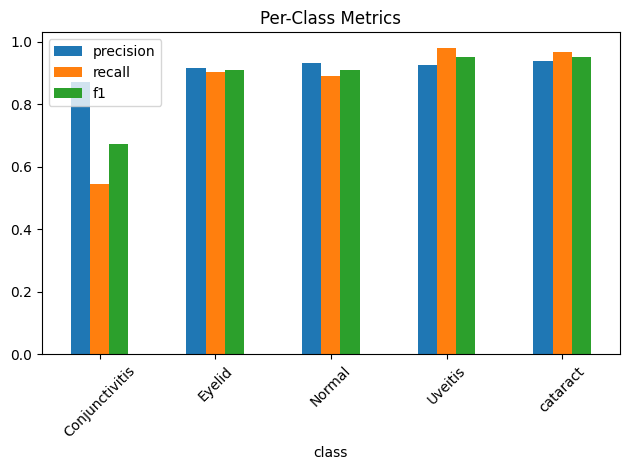

In [ ]:
import matplotlib.pyplot as plt

df_metrics.set_index("class")[["precision", "recall", "f1"]].plot(kind="bar")
plt.title("Per-Class Metrics")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from ultralytics.utils.metrics import ConfusionMatrix

cm = ConfusionMatrix(nc=len(model.names))

# run prediction validation again to fill matrix
model.val(
    data="/content/datasets/eye_disease_data_colab.yaml",
    plots=True,
    save_json=False
)

# plot confusion matrix
cm.plot(save_dir="/content/")

Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)


val: Scanning /content/datasets/eye_final_yolo12/valid/labels.cache... 3137 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3137/3137 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/106_jpg.rf.7716bc712afe8b42653ed57f84d43c7c.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/106_jpg.rf.7716bc712afe8b42653ed57f84d43c7c_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/130_jpg.rf.ae966855f2a749035e0c6f15bd1ad07e.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/130_jpg.rf.ae966855f2a749035e0c6f15bd1ad07e_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/130_jpg.rf.ed91b6ec02d911c4acbf89533249df47_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/158_jpg.rf.e601f4929a89aab9846059164e007485_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/160_jpeg.rf.63a7aea30d5e2513935a5c6f4d1aa1e7_aug0.jpg: 1 duplicate labels re


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 197/197 [00:39<00:00,  4.95it/s]


                   all       3137      11307      0.916      0.857      0.917      0.804
        Conjunctivitis        690       2571       0.87      0.546       0.72      0.507
                Eyelid       1292       1850      0.917      0.903       0.95      0.847
                Normal       1316       1860       0.93       0.89      0.948       0.84
               Uveitis       1180       1488      0.925      0.981      0.987      0.913
              cataract       2155       3538      0.938      0.966      0.981      0.913
Speed: 0.2ms preprocess, 4.3ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/yolov12/runs/detect/val2


In [ ]:
cm.plot(normalize=True, save_dir="/content/")

In [ ]:
cm.plot(normalize=True, save_dir="/content/")

In [ ]:
results = model.predict(
    source="/content/datasets/eye_final/valid/images",
    conf=0.25,
    save=True
)


image 1/452 /content/datasets/eye_final/valid/images/102_jpg.rf.2fa14224e1d64e1ff573ef81cf0d3931.jpg: 512x512 1 Eyelid, 2 Normals, 1 Uveitis, 1 cataract, 20.3ms
image 2/452 /content/datasets/eye_final/valid/images/102_jpg.rf.2fa14224e1d64e1ff573ef81cf0d3931_aug0.jpg: 512x512 1 Eyelid, 2 Normals, 1 Uveitis, 1 cataract, 15.6ms
image 3/452 /content/datasets/eye_final/valid/images/102_jpg.rf.9f05e9ca81a2e0eb92991e9c6ddf431f.jpg: 512x512 1 cataract, 17.4ms
image 4/452 /content/datasets/eye_final/valid/images/102_jpg.rf.9f05e9ca81a2e0eb92991e9c6ddf431f_aug0.jpg: 512x512 1 cataract, 15.6ms
image 5/452 /content/datasets/eye_final/valid/images/103_jpg.rf.d8afb62ae46fbfd11f00eb5f3d464302.jpg: 512x512 1 Normal, 4 cataracts, 15.0ms
image 6/452 /content/datasets/eye_final/valid/images/103_jpg.rf.d8afb62ae46fbfd11f00eb5f3d464302_aug0.jpg: 512x512 1 Normal, 4 cataracts, 30.5ms
image 7/452 /content/datasets/eye_final/valid/images/104_jpg.rf.66ca46bb4eb003f4df39fe8609cab0c7.jpg: 512x512 1 Uveitis, 3 c

In [ ]:
print("\n===== SUMMARY =====")
print(df_metrics.sort_values("f1", ascending=False))


===== SUMMARY =====
            class  precision    recall        f1      ap50   ap50-95
4        cataract   0.938041  0.966083  0.951855  0.980570  0.912715
3         Uveitis   0.924551  0.980511  0.951708  0.986756  0.912811
1          Eyelid   0.916795  0.903243  0.909968  0.949556  0.846969
2          Normal   0.930231  0.890323  0.909839  0.948246  0.840270
0  Conjunctivitis   0.870385  0.545883  0.670958  0.719614  0.506757


In [ ]:
from ultralytics import YOLO

# load model terbaik
model = YOLO("/content/yolov12/runs/detect/train4/weights/best.pt")

# evaluasi
metrics = model.val(
    split="val",
    save=True,
    plots=True  #
)

Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12 summary (fused): 402 layers, 2,519,755 parameters, 0 gradients, 5.8 GFLOPs


val: Scanning /content/datasets/eye_final_yolo12/valid/labels.cache... 3137 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3137/3137 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/106_jpg.rf.7716bc712afe8b42653ed57f84d43c7c.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/106_jpg.rf.7716bc712afe8b42653ed57f84d43c7c_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/130_jpg.rf.ae966855f2a749035e0c6f15bd1ad07e.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/130_jpg.rf.ae966855f2a749035e0c6f15bd1ad07e_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/130_jpg.rf.ed91b6ec02d911c4acbf89533249df47_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/158_jpg.rf.e601f4929a89aab9846059164e007485_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/160_jpeg.rf.63a7aea30d5e2513935a5c6f4d1aa1e7_aug0.jpg: 1 duplicate labels re


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 197/197 [00:39<00:00,  4.97it/s]


                   all       3137      11307      0.916      0.857      0.917      0.804
        Conjunctivitis        690       2571       0.87      0.546       0.72      0.507
                Eyelid       1292       1850      0.917      0.903       0.95      0.847
                Normal       1316       1860       0.93       0.89      0.948       0.84
               Uveitis       1180       1488      0.925      0.981      0.987      0.913
              cataract       2155       3538      0.938      0.966      0.981      0.913
Speed: 0.2ms preprocess, 4.3ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/yolov12/runs/detect/val3


In [ ]:
metrics = model.val(
    split="val",
    project="runs/eval",
    name="cbam_test",
    save=True,
    plots=True
)

Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)


val: Scanning /content/datasets/eye_final_yolo12/valid/labels.cache... 3137 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3137/3137 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/106_jpg.rf.7716bc712afe8b42653ed57f84d43c7c.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/106_jpg.rf.7716bc712afe8b42653ed57f84d43c7c_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/130_jpg.rf.ae966855f2a749035e0c6f15bd1ad07e_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/130_jpg.rf.ed91b6ec02d911c4acbf89533249df47_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/158_jpg.rf.e601f4929a89aab9846059164e007485_aug0.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/160_jpeg.rf.63a7aea30d5e2513935a5c6f4d1aa1e7.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/eye_final_yolo12/valid/images/196_jpg.rf.99b9cec785376c94745bd182474567f8.jpg: 1 duplicate labels removed


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 197/197 [00:38<00:00,  5.08it/s]


                   all       3137      11433      0.907      0.851      0.912      0.796
        Conjunctivitis        709       2623      0.824      0.548      0.704      0.491
                Eyelid       1286       1850      0.892      0.889      0.943      0.836
                Normal       1315       1871      0.938      0.882      0.948      0.828
               Uveitis       1175       1474      0.931      0.974      0.985      0.917
              cataract       2185       3615      0.951      0.962      0.982      0.909
Speed: 0.2ms preprocess, 4.2ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/eval/cbam_test


In [ ]:
!pip install grad-cam

Using device: cuda
✅ Image: /content/drive/MyDrive/umn.v5i.yolov8-20260408T030729Z-3-001/umn.v5i.yolov8/train/images/179_jpg.rf.8cdae815c764cc95e9591d3236982f04.jpg


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


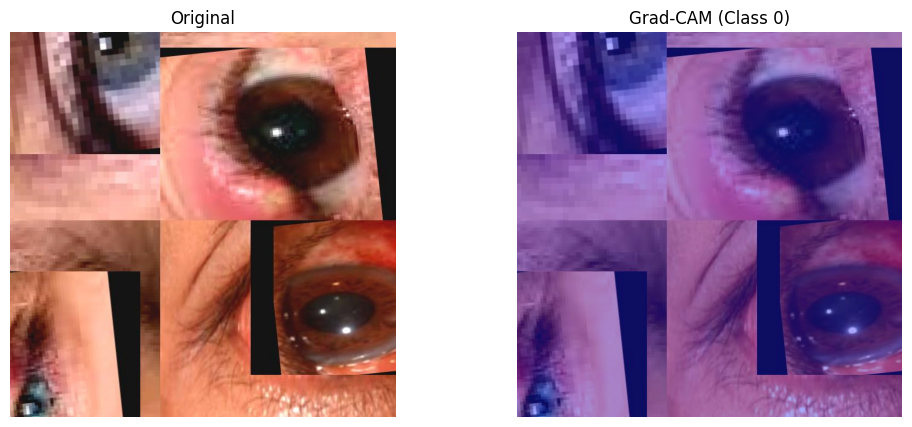

✅ DONE


In [ ]:
# ==========================================
# 1. INSTALL
# ==========================================
!pip install grad-cam -q

# ==========================================
# 2. IMPORT
# ==========================================
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from ultralytics import YOLO
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ==========================================
# 3. DEVICE
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ==========================================
# 4. LOAD MODEL
# ==========================================
model = YOLO("/content/yolov12/runs/detect/train4/weights/best.pt")
model.model.to(device)
model.model.eval()

# ==========================================
# 5. AUTO CARI GAMBAR
# ==========================================
def find_real_image(root="/content"):
    for r, d, f in os.walk(root):
        for file in f:
            if file.lower().endswith((".jpg",".jpeg",".png")):
                if "confusion" not in file.lower():
                    return os.path.join(r, file)
    return None

img_path = find_real_image()
print("✅ Image:", img_path)

# ==========================================
# 6. LOAD IMAGE
# ==========================================
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (640, 640))
img_norm = img_resized.astype(np.float32) / 255.0

input_tensor = torch.from_numpy(img_norm).permute(2,0,1).unsqueeze(0).to(device)
input_tensor.requires_grad = True

# ==========================================
# 7. WRAPPER MODEL
# ==========================================
class YOLOWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        outputs = self.model(x)
        if isinstance(outputs, (list, tuple)):
            outputs = outputs[0]
        return outputs

wrapped_model = YOLOWrapper(model.model)

# ==========================================
# 8. CUSTOM TARGET (INI KUNCI 🔥)
# ==========================================
class YOLOBoxScoreTarget:
    def __init__(self, class_id):
        self.class_id = class_id

    def __call__(self, model_output):
        # model_output shape: [N, num_boxes, (x,y,w,h,conf,cls...)]

        if model_output.ndim == 3:
            # ambil score class tertentu
            class_scores = model_output[..., 5 + self.class_id]
            return class_scores.max()
        else:
            return model_output.max()

# ==========================================
# 9. PILIH CLASS (Conjunctivitis = 0)
# ==========================================
target_class = 0

targets = [YOLOBoxScoreTarget(target_class)]

# ==========================================
# 10. TARGET LAYER
# ==========================================
target_layers = [model.model.model[-3]]

# ==========================================
# 11. GRAD-CAM
# ==========================================
cam = GradCAM(model=wrapped_model, target_layers=target_layers)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)[0]

# ==========================================
# 12. VISUALISASI
# ==========================================
visualization = show_cam_on_image(img_norm, grayscale_cam, use_rgb=True)

# ==========================================
# 13. PLOT
# ==========================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title(f"Grad-CAM (Class {target_class})")
plt.imshow(visualization)
plt.axis("off")

plt.show()

# ==========================================
# 14. SAVE
# ==========================================
cv2.imwrite("/content/gradcam_result.jpg",
            cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR))

print("✅ DONE")

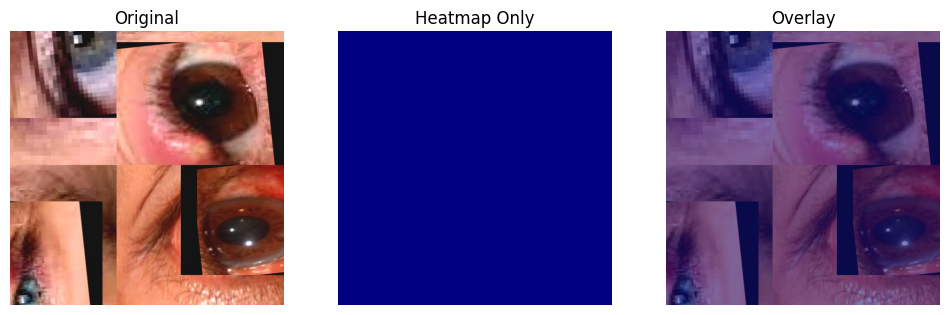

In [ ]:
# =========================
# NORMALISASI HEATMAP
# =========================
cam = grayscale_cam.copy()

# normalize ke 0–1
cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# OPTIONAL: tingkatkan kontras (gamma correction)
gamma = 1.5  # bisa 1.2–2.0
cam = np.power(cam, gamma)

# =========================
# UBAH KE HEATMAP WARNA
# =========================
heatmap = cv2.applyColorMap(
    np.uint8(255 * cam),
    cv2.COLORMAP_JET   # 🔥 penting
)

heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

# =========================
# OVERLAY (BLENDING)
# =========================
alpha = 0.5  # transparansi heatmap

overlay = heatmap * alpha + img_resized * (1 - alpha)
overlay = np.clip(overlay, 0, 255).astype(np.uint8)

# =========================
# PLOT
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Heatmap Only")
plt.imshow(heatmap)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()

In [ ]:
# ==========================================
# 1. IMPORT
# ==========================================
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pytorch_grad_cam import GradCAM

# ==========================================
# 2. LOAD MODEL
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"

model = YOLO("/content/yolov12/runs/detect/train4/weights/best.pt")
model.model.to(device)
model.model.eval()

# ==========================================
# 3. LOAD IMAGE
# ==========================================
img_path = "/content/datasets/eye_final_yolo12/train/images/141_jpg.rf.d95c9d77984cb1f6fe7a171e5ee21021.jpg"

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# ==========================================
# 4. DETEKSI
# ==========================================
results = model(img_path)[0]

boxes = results.boxes.xyxy.cpu().numpy()
classes = results.boxes.cls.cpu().numpy()

print("Detected:", classes)

# ==========================================
# 5. WRAPPER YOLO
# ==========================================
class YOLOWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        if isinstance(out, (list, tuple)):
            out = out[0]
        return out

wrapped_model = YOLOWrapper(model.model)

# ==========================================
# 6. CUSTOM TARGET
# ==========================================
class YOLOBoxScoreTarget:
    def __init__(self, class_id):
        self.class_id = class_id

    def __call__(self, output):
        if output.ndim == 3:
            scores = output[..., 5 + self.class_id]
            return scores.max()
        return output.max()

# ==========================================
# 7. TARGET LAYER
# ==========================================
target_layers = [model.model.model[-3]]
cam = GradCAM(model=wrapped_model, target_layers=target_layers)

# ==========================================
# 8. LOOP PER BBOX
# ==========================================
output_img = img_rgb.copy()

for i, (box, cls) in enumerate(zip(boxes, classes)):

    x1, y1, x2, y2 = map(int, box)

    # Crop ROI
    roi = img_rgb[y1:y2, x1:x2]

    if roi.size == 0:
        continue

    roi_resized = cv2.resize(roi, (640, 640))
    roi_norm = roi_resized.astype(np.float32) / 255.0

    input_tensor = torch.from_numpy(roi_norm).permute(2,0,1).unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    # Target class
    target = [YOLOBoxScoreTarget(int(cls))]

    # Grad-CAM
    grayscale_cam = cam(input_tensor=input_tensor, targets=target)[0]

    # Normalize
    cam_map = (grayscale_cam - grayscale_cam.min()) / (grayscale_cam.max() - grayscale_cam.min() + 1e-8)

    # Heatmap
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_map),
        cv2.COLORMAP_TURBO
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Resize ke bbox size
    heatmap = cv2.resize(heatmap, (x2 - x1, y2 - y1))

    # Overlay ke original image
    alpha = 0.5
    output_img[y1:y2, x1:x2] = (
        heatmap * alpha + output_img[y1:y2, x1:x2] * (1 - alpha)
    ).astype(np.uint8)

    # Draw bounding box
    cv2.rectangle(output_img, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(output_img, f"Class {int(cls)}",
                (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (0,255,0), 1)

# ==========================================
# 9. PLOT
# ==========================================
plt.figure(figsize=(8,8))
plt.imshow(output_img)
plt.title("Grad-CAM per Bounding Box")
plt.axis("off")
plt.show()

# ==========================================
# 10. SAVE
# ==========================================
cv2.imwrite("/content/gradcam_bbox.jpg",
            cv2.cvtColor(output_img, cv2.COLOR_RGB2BGR))

print("✅ Saved: /content/gradcam_bbox.jpg")

error: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'



image 1/1 /content/datasets/eye_final_yolo12/test/images/101_jpg.rf.5a1328a0ece1cef5264ceb1dd5d66b37_aug2.jpg: 512x512 1 Uveitis, 18.8ms
Speed: 3.1ms preprocess, 18.8ms inference, 1.5ms postprocess per image at shape (1, 3, 512, 512)
Detected 1 object(s):
  [0] Uveitis — conf: 0.86


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/tmp/ipykernel_25055/3412281068.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.5)


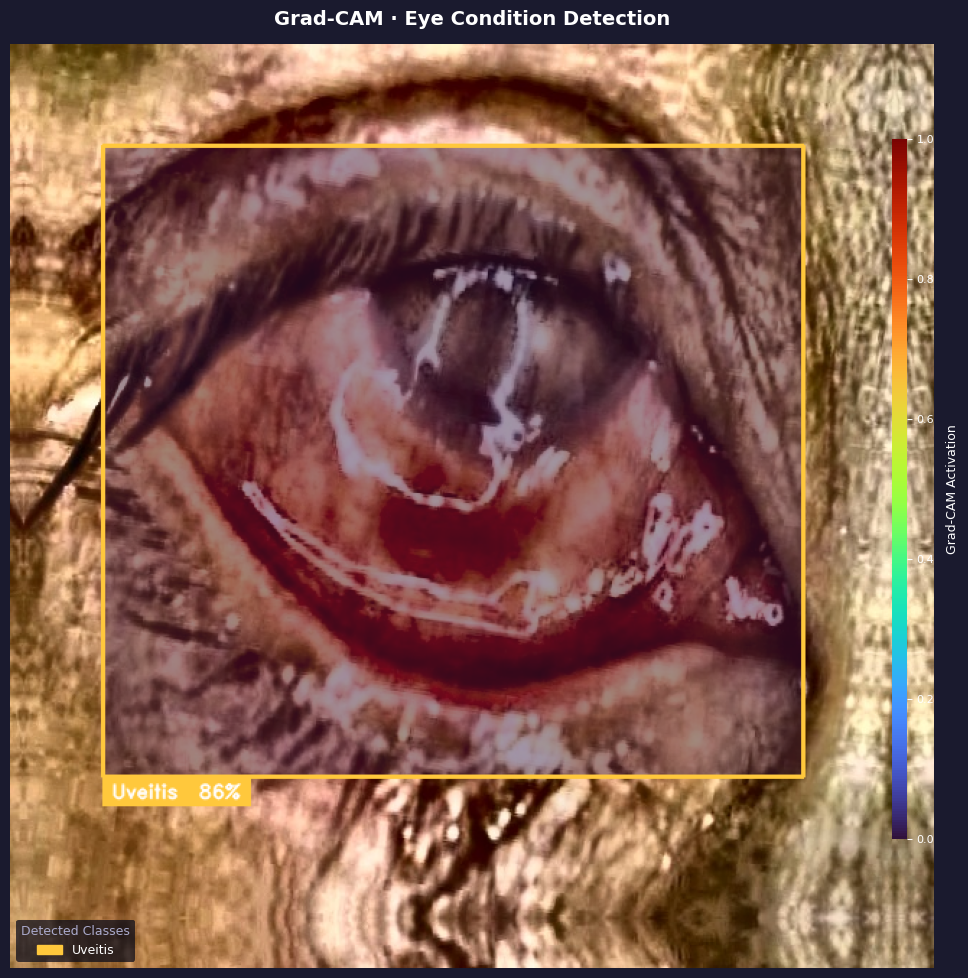

✅ Saved: /content/gradcam_professional.jpg


In [ ]:
# ==========================================
# 1. IMPORT
# ==========================================
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from ultralytics import YOLO
from pytorch_grad_cam import GradCAM

# ==========================================
# 2. KONFIGURASI
# ==========================================
CLASS_NAMES = {
    0: "Conjunctivitis",
    1: "Eyelid",
    2: "Normal",
    3: "Uveitis",
    4: "Cataract"
}

CLASS_COLORS = {
    0: (255, 80,  80),   # merah    - Conjunctivitis
    1: (80,  200, 255),  # biru     - Eyelid
    2: (80,  230, 120),  # hijau    - Normal
    3: (255, 200, 60),   # kuning   - Uveitis
    4: (200, 130, 255),  # ungu     - Cataract
}

# ==========================================
# 3. LOAD MODEL
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"

model = YOLO("/content/yolov12/runs/detect/train4/weights/best.pt")
model.model.to(device)
model.model.eval()

# ==========================================
# 4. LOAD IMAGE
# ==========================================
img_path = "/content/datasets/eye_final_yolo12/test/images/101_jpg.rf.5a1328a0ece1cef5264ceb1dd5d66b37_aug2.jpg"

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# ==========================================
# 5. DETEKSI
# ==========================================
results = model(img_path)[0]

boxes   = results.boxes.xyxy.cpu().numpy()
classes = results.boxes.cls.cpu().numpy()
confs   = results.boxes.conf.cpu().numpy()

print(f"Detected {len(classes)} object(s):")
for i, (cls, conf) in enumerate(zip(classes, confs)):
    print(f"  [{i}] {CLASS_NAMES.get(int(cls), f'Class {int(cls)}')} — conf: {conf:.2f}")

# ==========================================
# 6. WRAPPER YOLO
# ==========================================
class YOLOWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        if isinstance(out, (list, tuple)):
            out = out[0]
        return out

wrapped_model = YOLOWrapper(model.model)

# ==========================================
# 7. CUSTOM TARGET
# ==========================================
class YOLOBoxScoreTarget:
    def __init__(self, class_id):
        self.class_id = class_id

    def __call__(self, output):
        if output.ndim == 3:
            scores = output[..., 5 + self.class_id]
            return scores.max()
        return output.max()

# ==========================================
# 8. TARGET LAYER
# ==========================================
target_layers = [model.model.model[-3]]
cam = GradCAM(model=wrapped_model, target_layers=target_layers)

# ==========================================
# 9. LOOP PER BBOX — GRAD-CAM + OVERLAY
# ==========================================
output_img = img_rgb.copy()

for i, (box, cls, conf) in enumerate(zip(boxes, classes, confs)):

    x1, y1, x2, y2 = map(int, box)
    cls_id    = int(cls)
    cls_name  = CLASS_NAMES.get(cls_id, f"Class {cls_id}")
    color_rgb = CLASS_COLORS.get(cls_id, (200, 200, 200))

    # ---- Crop ROI ----
    roi = img_rgb[y1:y2, x1:x2]
    if roi.size == 0:
        continue

    roi_resized = cv2.resize(roi, (640, 640))
    roi_norm    = roi_resized.astype(np.float32) / 255.0

    input_tensor = (
        torch.from_numpy(roi_norm)
        .permute(2, 0, 1)
        .unsqueeze(0)
        .to(device)
    )
    input_tensor.requires_grad = True

    # ---- Grad-CAM ----
    target        = [YOLOBoxScoreTarget(cls_id)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=target)[0]

    cam_map = (
        (grayscale_cam - grayscale_cam.min())
        / (grayscale_cam.max() - grayscale_cam.min() + 1e-8)
    )

    # ---- Heatmap overlay ----
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_map), cv2.COLORMAP_TURBO)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = cv2.resize(heatmap, (x2 - x1, y2 - y1))

    alpha = 0.45
    output_img[y1:y2, x1:x2] = (
        heatmap * alpha + output_img[y1:y2, x1:x2] * (1 - alpha)
    ).astype(np.uint8)

    # ---- Bounding box ----
    thickness = 2
    cv2.rectangle(output_img, (x1, y1), (x2, y2), color_rgb, thickness)

    # ---- Label background pill ----
    label_text = f"{cls_name}  {conf:.0%}"
    font       = cv2.FONT_HERSHEY_DUPLEX
    font_scale = 0.45
    font_thick = 1

    (tw, th), baseline = cv2.getTextSize(label_text, font, font_scale, font_thick)
    pad_x, pad_y = 6, 4

    # Posisi label: di bawah bbox (tidak keluar frame)
    lx1 = x1
    ly1 = y2 + 2
    lx2 = x1 + tw + pad_x * 2
    ly2 = y2 + 2 + th + pad_y * 2

    # Pastikan tidak keluar dari tepi gambar
    if ly2 > h:
        ly1 = y1 - (th + pad_y * 2) - 2
        ly2 = y1 - 2

    # Kliping horizontal
    lx2 = min(lx2, w)

    # Gambar background pill
    cv2.rectangle(output_img, (lx1, ly1), (lx2, ly2), color_rgb, -1)
    cv2.rectangle(output_img, (lx1, ly1), (lx2, ly2), color_rgb, 1)

    # Teks putih di atas background
    cv2.putText(
        output_img,
        label_text,
        (lx1 + pad_x, ly2 - pad_y - 1),
        font,
        font_scale,
        (255, 255, 255),
        font_thick,
        cv2.LINE_AA
    )

# ==========================================
# 10. PLOT PROFESIONAL
# ==========================================
fig, ax = plt.subplots(figsize=(10, 10), facecolor="#1a1a2e")
ax.set_facecolor("#1a1a2e")

ax.imshow(output_img)
ax.axis("off")

# Judul
ax.set_title(
    "Grad-CAM · Eye Condition Detection",
    color="white",
    fontsize=14,
    fontweight="semibold",
    pad=14,
    fontfamily="DejaVu Sans"
)

# Legend
legend_patches = []
detected_ids   = sorted(set(int(c) for c in classes))
for cls_id in detected_ids:
    name  = CLASS_NAMES.get(cls_id, f"Class {cls_id}")
    color = tuple(v / 255 for v in CLASS_COLORS.get(cls_id, (200, 200, 200)))
    patch = mpatches.Patch(color=color, label=name)
    legend_patches.append(patch)

legend = ax.legend(
    handles=legend_patches,
    loc="lower left",
    frameon=True,
    framealpha=0.75,
    facecolor="#0d0d1a",
    edgecolor="none",
    labelcolor="white",
    fontsize=9,
    title="Detected Classes",
    title_fontsize=9,
)
legend.get_title().set_color("#aaaacc")

# Colorbar Grad-CAM
cax = fig.add_axes([0.92, 0.15, 0.015, 0.70])
sm  = plt.cm.ScalarMappable(cmap="turbo", norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Grad-CAM Activation", color="white", fontsize=9, labelpad=8)
cbar.ax.yaxis.set_tick_params(color="white", labelsize=8)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
cbar.outline.set_edgecolor("none")

plt.tight_layout(pad=1.5)
plt.savefig(
    "/content/gradcam_professional.jpg",
    dpi=180,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
plt.show()

print("✅ Saved: /content/gradcam_professional.jpg")


image 1/1 /content/datasets/eye_final_yolo12/test/images/101_jpg.rf.5a1328a0ece1cef5264ceb1dd5d66b37_aug2.jpg: 512x512 1 Uveitis, 15.0ms
Speed: 2.0ms preprocess, 15.0ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 512)
Detected 1 object(s):
  [0] Uveitis — 85.9%


ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

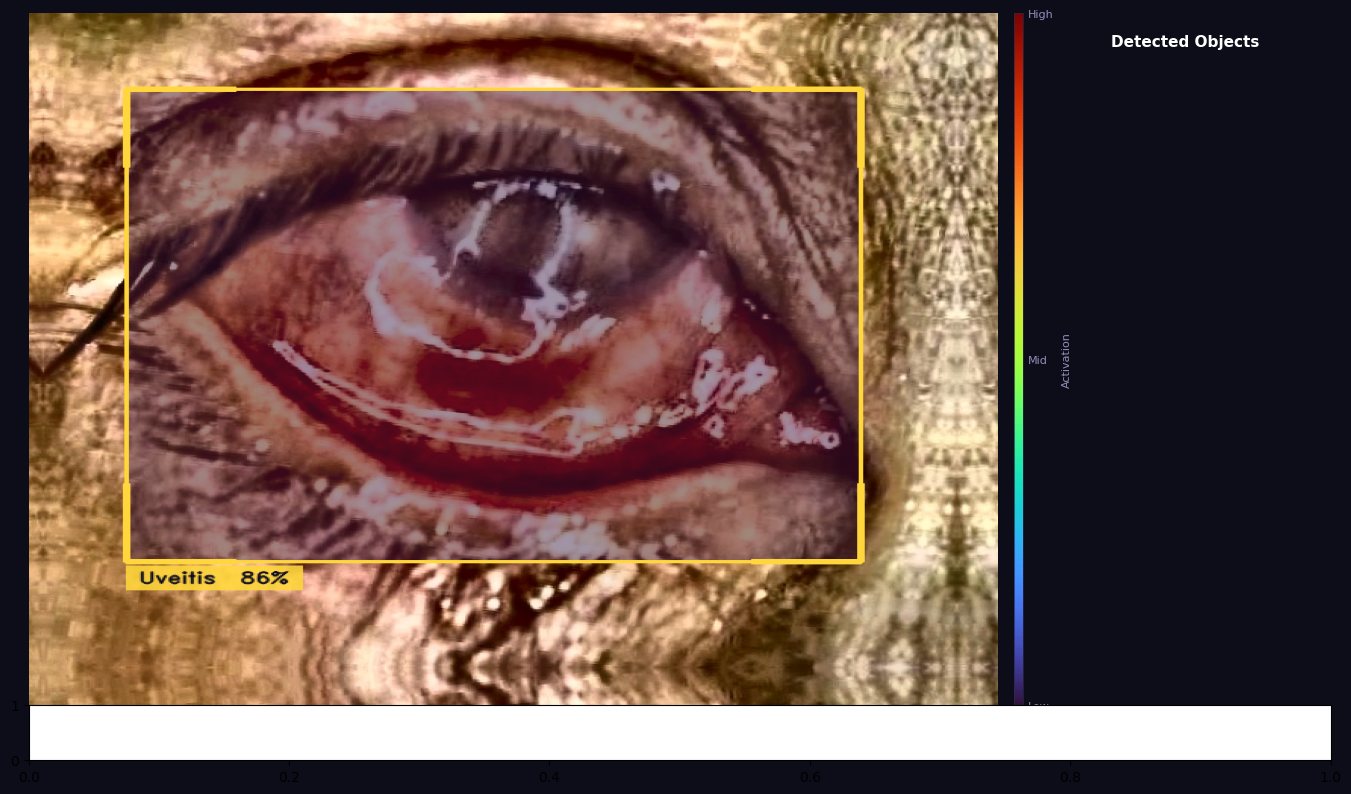

In [ ]:
# ==========================================
# GRAD-CAM · EYE CONDITION DETECTION
# Ultra-Professional Visualization
# ==========================================

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import font_manager
from ultralytics import YOLO
from pytorch_grad_cam import GradCAM

# ==========================================
# CONFIG
# ==========================================
CLASS_NAMES = {
    0: "Conjunctivitis",
    1: "Eyelid",
    2: "Normal",
    3: "Uveitis",
    4: "Cataract",
}

# Palette — warna solid, tinggi kontras di atas gelap
CLASS_PALETTE = {
    0: {"rgb": (255,  90,  90), "hex": "#FF5A5A"},  # merah
    1: {"rgb": ( 64, 196, 255), "hex": "#40C4FF"},  # biru langit
    2: {"rgb": ( 80, 230, 120), "hex": "#50E678"},  # hijau
    3: {"rgb": (255, 214,  60), "hex": "#FFD63C"},  # kuning emas
    4: {"rgb": (190, 130, 255), "hex": "#BE82FF"},  # ungu
}

BG_DARK   = "#0D0D1A"
BG_PANEL  = "#13132B"
BG_CARD   = "#1A1A35"
ACCENT    = "#7C6FF7"
TEXT_PRI  = "#FFFFFF"
TEXT_SEC  = "#9090BB"
BORDER    = "#2A2A50"

# ==========================================
# LOAD MODEL
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"

model = YOLO("/content/yolov12/runs/detect/train4/weights/best.pt")
model.model.to(device)
model.model.eval()

# ==========================================
# LOAD IMAGE
# ==========================================
img_path = "/content/datasets/eye_final_yolo12/test/images/101_jpg.rf.5a1328a0ece1cef5264ceb1dd5d66b37_aug2.jpg"

img     = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w    = img.shape[:2]

# ==========================================
# DETEKSI
# ==========================================
results = model(img_path)[0]
boxes   = results.boxes.xyxy.cpu().numpy()
classes = results.boxes.cls.cpu().numpy()
confs   = results.boxes.conf.cpu().numpy()

print(f"Detected {len(classes)} object(s):")
for i, (cls, conf) in enumerate(zip(classes, confs)):
    print(f"  [{i}] {CLASS_NAMES[int(cls)]} — {conf:.1%}")

# ==========================================
# YOLO WRAPPER
# ==========================================
class YOLOWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        out = self.model(x)
        return out[0] if isinstance(out, (list, tuple)) else out

class YOLOBoxScoreTarget:
    def __init__(self, class_id):
        self.class_id = class_id
    def __call__(self, output):
        if output.ndim == 3:
            return output[..., 5 + self.class_id].max()
        return output.max()

wrapped_model = YOLOWrapper(model.model)
target_layers = [model.model.model[-3]]
cam           = GradCAM(model=wrapped_model, target_layers=target_layers)

# ==========================================
# GRAD-CAM OVERLAY
# ==========================================
output_img = img_rgb.copy()

for box, cls, conf in zip(boxes, classes, confs):
    x1, y1, x2, y2 = map(int, box)
    cls_id  = int(cls)
    color   = CLASS_PALETTE[cls_id]["rgb"]
    name    = CLASS_NAMES[cls_id]

    roi = img_rgb[y1:y2, x1:x2]
    if roi.size == 0:
        continue

    roi_resized = cv2.resize(roi, (640, 640))
    input_tensor = (
        torch.from_numpy(roi_resized.astype(np.float32) / 255.0)
        .permute(2,0,1).unsqueeze(0).to(device)
    )
    input_tensor.requires_grad = True

    grayscale_cam = cam(input_tensor=input_tensor,
                        targets=[YOLOBoxScoreTarget(cls_id)])[0]
    cam_map = (grayscale_cam - grayscale_cam.min()) / (grayscale_cam.max() - grayscale_cam.min() + 1e-8)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam_map), cv2.COLORMAP_TURBO)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = cv2.resize(heatmap, (x2 - x1, y2 - y1))

    output_img[y1:y2, x1:x2] = (
        heatmap * 0.45 + output_img[y1:y2, x1:x2] * 0.55
    ).astype(np.uint8)

    # --- Bounding box (rounded feel via double-line trick) ---
    cv2.rectangle(output_img, (x1, y1), (x2, y2), color, 2)
    # Sudut kecil dekoratif
    corner_len = min((x2-x1), (y2-y1)) // 6
    for cx, cy, dx, dy in [(x1,y1,1,1),(x2,y1,-1,1),(x1,y2,1,-1),(x2,y2,-1,-1)]:
        cv2.line(output_img, (cx, cy), (cx + dx*corner_len, cy), color, 4)
        cv2.line(output_img, (cx, cy), (cx, cy + dy*corner_len), color, 4)

    # --- Label pill di BAWAH bbox ---
    label   = f"{name}  {conf:.0%}"
    font    = cv2.FONT_HERSHEY_DUPLEX
    fscale  = 0.50
    fthick  = 1
    (tw, th), _ = cv2.getTextSize(label, font, fscale, fthick)
    px, py  = 8, 5

    lx1 = x1
    ly1 = y2 + 4
    lx2 = min(x1 + tw + px*2, w)
    ly2 = min(y2 + 4 + th + py*2, h)

    if ly2 > h:
        ly1 = max(y1 - th - py*2 - 4, 0)
        ly2 = max(y1 - 4, th + py*2)

    # Background solid pill
    overlay = output_img.copy()
    cv2.rectangle(overlay, (lx1, ly1), (lx2, ly2), color, -1)
    cv2.addWeighted(overlay, 0.9, output_img, 0.1, 0, output_img)

    # Teks
    cv2.putText(output_img, label,
                (lx1 + px, ly2 - py - 1),
                font, fscale, (10, 10, 30), fthick, cv2.LINE_AA)

# ==========================================
# LAYOUT FIGURE
# ==========================================
fig = plt.figure(figsize=(14, 9), facecolor=BG_DARK)

gs = gridspec.GridSpec(
    2, 3,
    figure=fig,
    width_ratios=[3, 0.03, 0.9],
    height_ratios=[1, 0.08],
    left=0.04, right=0.97,
    top=0.90, bottom=0.07,
    wspace=0.04, hspace=0.0,
)

ax_img  = fig.add_subplot(gs[0, 0])   # gambar utama
ax_cbar = fig.add_subplot(gs[0, 1])   # colorbar
ax_info = fig.add_subplot(gs[0, 2])   # panel kanan
ax_foot = fig.add_subplot(gs[1, :])   # footer

# ==========================================
# GAMBAR UTAMA
# ==========================================
ax_img.set_facecolor(BG_PANEL)
ax_img.imshow(output_img, aspect="auto")
ax_img.axis("off")

# Border tipis
for spine in ax_img.spines.values():
    spine.set_edgecolor(BORDER)
    spine.set_linewidth(0.8)
    spine.set_visible(True)

# ==========================================
# COLORBAR
# ==========================================
turbo_cmap = plt.cm.turbo
norm       = plt.Normalize(0, 1)
cb         = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=turbo_cmap),
    cax=ax_cbar,
)
cb.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cb.set_ticklabels(["Low", "", "Mid", "", "High"])
cb.ax.yaxis.set_tick_params(color=TEXT_SEC, labelsize=8, length=0)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=TEXT_SEC)
cb.outline.set_edgecolor(BORDER)
cb.outline.set_linewidth(0.5)
ax_cbar.set_facecolor(BG_DARK)
cb.set_label("Activation", color=TEXT_SEC, fontsize=8, labelpad=6)

# ==========================================
# PANEL INFO KANAN
# ==========================================
ax_info.set_facecolor(BG_CARD)
ax_info.axis("off")

for spine in ax_info.spines.values():
    spine.set_edgecolor(BORDER)
    spine.set_linewidth(0.6)
    spine.set_visible(True)

# Judul panel
ax_info.text(
    0.5, 0.97, "Detected Objects",
    transform=ax_info.transAxes,
    ha="center", va="top",
    fontsize=11, fontweight="semibold",
    color=TEXT_PRI,
)
ax_info.axhline(y=0.935, xmin=0.06, xmax=0.94,
                color=BORDER, linewidth=0.8,
                transform=ax_info.transAxes)

# Kartu per deteksi
n = len(classes)
card_h = 0.12
start_y = 0.90

for i, (cls, conf) in enumerate(zip(classes, confs)):
    cls_id  = int(cls)
    name    = CLASS_NAMES[cls_id]
    color_h = CLASS_PALETTE[cls_id]["hex"]
    color_r = tuple(v/255 for v in CLASS_PALETTE[cls_id]["rgb"])

    y_card = start_y - i * (card_h + 0.025)
    if y_card < 0.04:
        break

    # Background kartu
    card_rect = FancyBboxPatch(
        (0.06, y_card - card_h),
        0.88, card_h,
        boxstyle="round,pad=0.01",
        facecolor=BG_PANEL,
        edgecolor=color_h,
        linewidth=0.8,
        transform=ax_info.transAxes,
        clip_on=False,
    )
    ax_info.add_patch(card_rect)

    # Dot warna
    ax_info.plot(
        0.13, y_card - card_h/2,
        "o", ms=6,
        color=color_r,
        transform=ax_info.transAxes,
        clip_on=False,
    )

    # Nama kelas
    ax_info.text(
        0.22, y_card - card_h/2 + 0.022,
        name,
        transform=ax_info.transAxes,
        ha="left", va="center",
        fontsize=9, fontweight="medium",
        color=TEXT_PRI,
        clip_on=False,
    )

    # Index deteksi kecil
    ax_info.text(
        0.22, y_card - card_h/2 - 0.022,
        f"Detection #{i+1}",
        transform=ax_info.transAxes,
        ha="left", va="center",
        fontsize=7.5,
        color=TEXT_SEC,
        clip_on=False,
    )

    # Confidence bar
    bar_x0, bar_y = 0.22, y_card - card_h/2 - 0.058
    bar_w_full = 0.68
    ax_info.add_patch(FancyBboxPatch(
        (bar_x0, bar_y), bar_w_full, 0.014,
        boxstyle="round,pad=0.002",
        facecolor=BORDER,
        edgecolor="none",
        transform=ax_info.transAxes,
        clip_on=False,
    ))
    ax_info.add_patch(FancyBboxPatch(
        (bar_x0, bar_y), bar_w_full * conf, 0.014,
        boxstyle="round,pad=0.002",
        facecolor=color_r,
        edgecolor="none",
        transform=ax_info.transAxes,
        clip_on=False,
    ))
    ax_info.text(
        bar_x0 + bar_w_full + 0.04, bar_y + 0.007,
        f"{conf:.0%}",
        transform=ax_info.transAxes,
        ha="left", va="center",
        fontsize=8, fontweight="medium",
        color=color_r,
        clip_on=False,
    )

# Total deteksi
ax_info.text(
    0.5, 0.025,
    f"{n} object{'s' if n!=1 else ''} detected  ·  YOLOv12",
    transform=ax_info.transAxes,
    ha="center", va="bottom",
    fontsize=7.5,
    color=TEXT_SEC,
)

# ==========================================
# FOOTER
# ==========================================
ax_foot.set_facecolor(BG_DARK)
ax_foot.axis("off")
ax_foot.text(
    0.0, 0.5,
    "Grad-CAM · Eye Condition Detection  |  Model: YOLOv12  |  Dataset: UMN v5",
    transform=ax_foot.transAxes,
    ha="left", va="center",
    fontsize=8,
    color=TEXT_SEC,
)
ax_foot.text(
    1.0, 0.5,
    "Classes: Conjunctivitis · Eyelid · Normal · Uveitis · Cataract",
    transform=ax_foot.transAxes,
    ha="right", va="center",
    fontsize=8,
    color=TEXT_SEC,
)

# ==========================================
# JUDUL UTAMA
# ==========================================
fig.text(
    0.5, 0.955,
    "Grad-CAM · Eye Condition Detection",
    ha="center", va="center",
    fontsize=16, fontweight="semibold",
    color=TEXT_PRI,
)
fig.text(
    0.5, 0.930,
    "Gradient-weighted Class Activation Mapping per Bounding Box",
    ha="center", va="center",
    fontsize=9,
    color=TEXT_SEC,
)

# Garis dekoratif di bawah judul
line_y = 0.918
fig.add_artist(plt.Line2D([0.04, 0.96], [line_y, line_y],
                           transform=fig.transFigure,
                           color=BORDER, linewidth=0.8))

# ==========================================
# SIMPAN & TAMPILKAN
# ==========================================
out_path = "/content/gradcam_ultra.jpg"
plt.savefig(
    out_path,
    dpi=200,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
    pil_kwargs={"quality": 97},
)
plt.show()
print(f"✅ Saved: {out_path}")


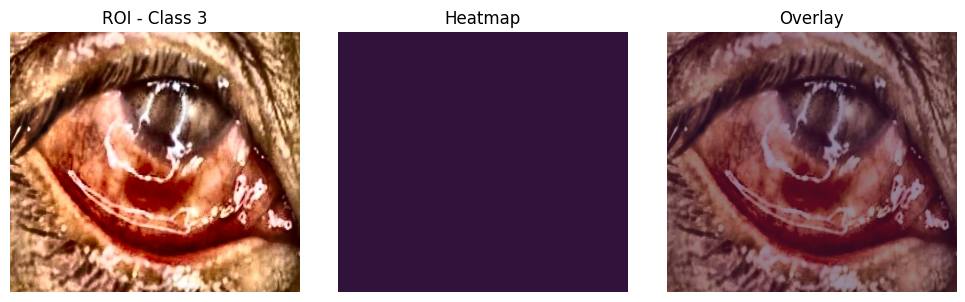

In [ ]:
# =========================
# Normalize (lebih kontras)
# =========================
cam_map = (grayscale_cam - grayscale_cam.min()) / (grayscale_cam.max() - grayscale_cam.min() + 1e-8)

# optional: tingkatkan kontras
cam_map = np.power(cam_map, 1.5)

# =========================
# Heatmap ONLY
# =========================
heatmap = cv2.applyColorMap(
    np.uint8(255 * cam_map),
    cv2.COLORMAP_TURBO   # 🔥 lebih bagus dari JET
)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

# =========================
# Resize ke ukuran bbox
# =========================
heatmap_resized = cv2.resize(heatmap, (x2 - x1, y2 - y1))
roi_original = img_rgb[y1:y2, x1:x2]

# =========================
# Overlay
# =========================
alpha = 0.5
overlay = (heatmap_resized * alpha + roi_original * (1 - alpha)).astype(np.uint8)

# =========================
# MASUKKAN KE GAMBAR UTAMA
# =========================
output_img[y1:y2, x1:x2] = overlay

# =========================
# VISUALISASI PER BBOX 🔥
# =========================
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.title(f"ROI - Class {int(cls)}")
plt.imshow(roi_original)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Heatmap")
plt.imshow(heatmap_resized)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

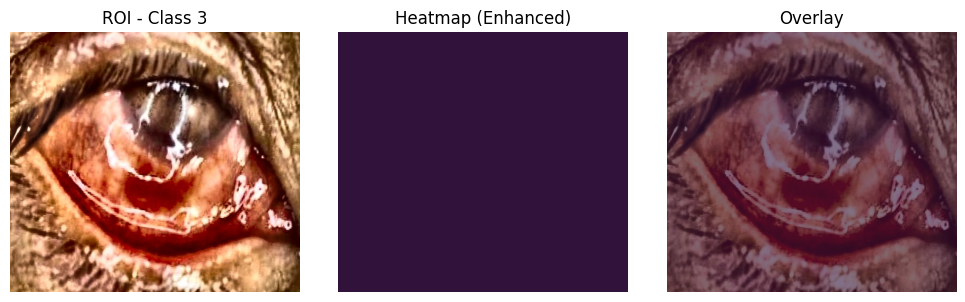

In [ ]:
# =========================
# NORMALISASI DASAR
# =========================
cam_map = (grayscale_cam - grayscale_cam.min()) / (grayscale_cam.max() - grayscale_cam.min() + 1e-8)

# =========================
# 🔥 1. SUPPRESS AREA TIDAK PENTING
# =========================
threshold = 0.1   # bisa 0.2–0.4
cam_map[cam_map < threshold] = cam_map[cam_map < threshold] * 0.3

# =========================
# 🔥 2. PERTEGAS AREA PENTING
# =========================
gamma = 2.2   # 🔥 makin besar → merah makin tajam
cam_map = np.power(cam_map, gamma)

# =========================
# 🔥 3. BOOST AREA PALING KUAT
# =========================
high_mask = cam_map > 0.7
cam_map[high_mask] = np.clip(cam_map[high_mask] * 1.3, 0, 1)

# =========================
# HEATMAP (WARNA KUAT)
# =========================
heatmap = cv2.applyColorMap(
    np.uint8(255 * cam_map),
    cv2.COLORMAP_TURBO   # 🔥 terbaik untuk kontras
)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

# =========================
# RESIZE KE BBOX
# =========================
heatmap_resized = cv2.resize(heatmap, (x2 - x1, y2 - y1))
roi_original = img_rgb[y1:y2, x1:x2]

# =========================
# OVERLAY (BIAR MERAH LEBIH DOMINAN)
# =========================
alpha = 0.6   # 🔥 naikkan biar merah lebih kuat
overlay = (heatmap_resized * alpha + roi_original * (1 - alpha)).astype(np.uint8)

# =========================
# MASUKKAN KE GAMBAR
# =========================
output_img[y1:y2, x1:x2] = overlay

# =========================
# VISUALISASI
# =========================
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.title(f"ROI - Class {int(cls)}")
plt.imshow(roi_original)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Heatmap (Enhanced)")
plt.imshow(heatmap_resized)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()